In [4]:
# =========================
# Shared Setup
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# Load data
customers = pd.read_csv(r"cleaned_data\customers_clean.csv")
orders = pd.read_csv(r"cleaned_data\orders_clean.csv")
payments = pd.read_csv(r"cleaned_data\payments_clean.csv")
order_items = pd.read_csv(r"cleaned_data\order_items_clean.csv")
products = pd.read_csv(r"cleaned_data\products_clean.csv")
sellers = pd.read_csv(r"cleaned_data\sellers_clean.csv")

# Date parsing
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"], format="mixed", errors="coerce")
orders["order_approved_at"] = pd.to_datetime(orders["order_approved_at"], format="mixed", errors="coerce")
orders["order_delivered_timestamp"] = pd.to_datetime(orders["order_delivered_timestamp"], format="mixed", errors="coerce")
orders["order_estimated_delivery"] = pd.to_datetime(orders["order_estimated_delivery"], format="mixed", errors="coerce")

# Helpers
comma_fmt = mticker.StrMethodFormatter("{x:,.0f}")

def rupee(x):
    return f"\u20b9{x:,.2f}"

def crore(x):
    return f"\u20b9{x/1e7:,.2f} Cr"

def add_bar_labels(ax, bars, fmt="{:,.0f}", is_horizontal=False, offset=3, fontsize=9):
    for bar in bars:
        if is_horizontal:
            val = bar.get_width()
            ax.text(val, bar.get_y() + bar.get_height()/2, f" {fmt.format(val)}",
                    va="center", ha="left", fontsize=fontsize, fontweight="bold")
        else:
            val = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, val, fmt.format(val),
                    ha="center", va="bottom", fontsize=fontsize, fontweight="bold")

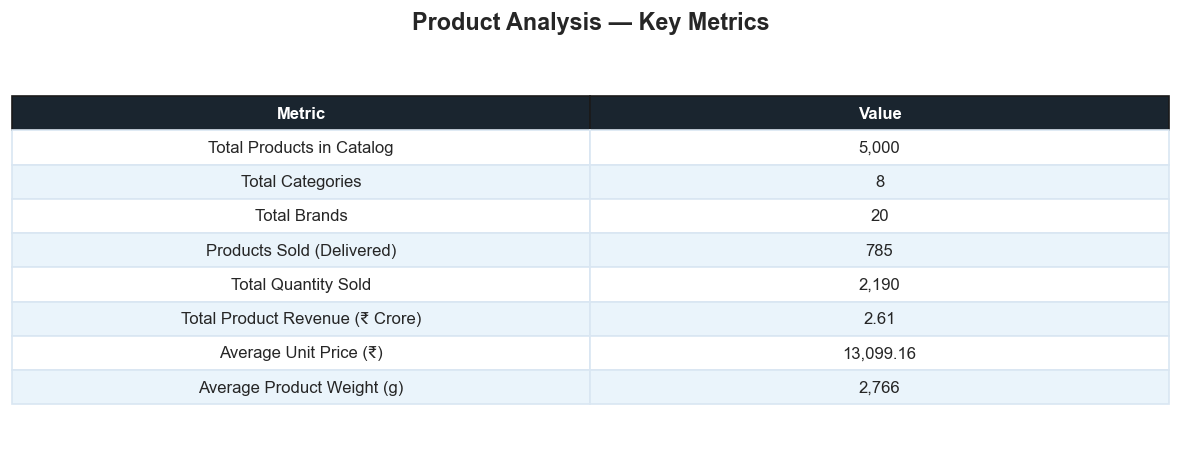

Raw Values:
Total Products: 5,000
Categories: 8
Brands: 20
Products Sold: 785
Total Quantity Sold: 2,190
Product Revenue: ₹26,126,426.45 (2.61 Cr)
Avg Unit Price: ₹13,099.16
Avg Weight: 2,766g


In [5]:
# =========================
# Section 1: Product KPI Summary
# =========================

delivered_orders = orders.loc[orders["order_status"].eq("delivered"), ["order_id"]].copy()

# Items from delivered orders merged with product info
item_full = (
    order_items.merge(delivered_orders, on="order_id", how="inner")
    .merge(products, on="product_id", how="left", suffixes=("", "_prod"))
)

total_products = products["product_id"].nunique()
total_categories = products["product_category"].nunique()
total_brands = products["brand"].nunique()
products_sold = item_full["product_id"].nunique()
total_quantity_sold = item_full["quantity"].sum()
product_revenue = item_full["total_value"].sum()
avg_unit_price = products["unit_price"].mean()
avg_weight = products["weight_grams"].mean()

kpi_df = pd.DataFrame({
    "Metric": [
        "Total Products in Catalog",
        "Total Categories",
        "Total Brands",
        "Products Sold (Delivered)",
        "Total Quantity Sold",
        "Total Product Revenue (\u20b9 Crore)",
        "Average Unit Price (\u20b9)",
        "Average Product Weight (g)"
    ],
    "Value": [
        f"{total_products:,}",
        f"{total_categories:,}",
        f"{total_brands:,}",
        f"{products_sold:,}",
        f"{total_quantity_sold:,.0f}",
        f"{product_revenue/1e7:,.2f}",
        f"{avg_unit_price:,.2f}",
        f"{avg_weight:,.0f}"
    ]
})

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")
ax.set_title("Product Analysis \u2014 Key Metrics", fontsize=14, fontweight="bold", pad=14)

tbl = ax.table(
    cellText=kpi_df.values,
    colLabels=kpi_df.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)

for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#1a252f")
        cell.set_text_props(color="white", weight="bold")
    else:
        cell.set_facecolor("#eaf4fb" if r % 2 == 0 else "white")
        cell.set_edgecolor("#d9e6f2")

plt.tight_layout()
plt.show()

print("Raw Values:")
print(f"Total Products: {total_products:,}")
print(f"Categories: {total_categories:,}")
print(f"Brands: {total_brands:,}")
print(f"Products Sold: {products_sold:,}")
print(f"Total Quantity Sold: {total_quantity_sold:,.0f}")
print(f"Product Revenue: \u20b9{product_revenue:,.2f} ({product_revenue/1e7:,.2f} Cr)")
print(f"Avg Unit Price: \u20b9{avg_unit_price:,.2f}")
print(f"Avg Weight: {avg_weight:,.0f}g")

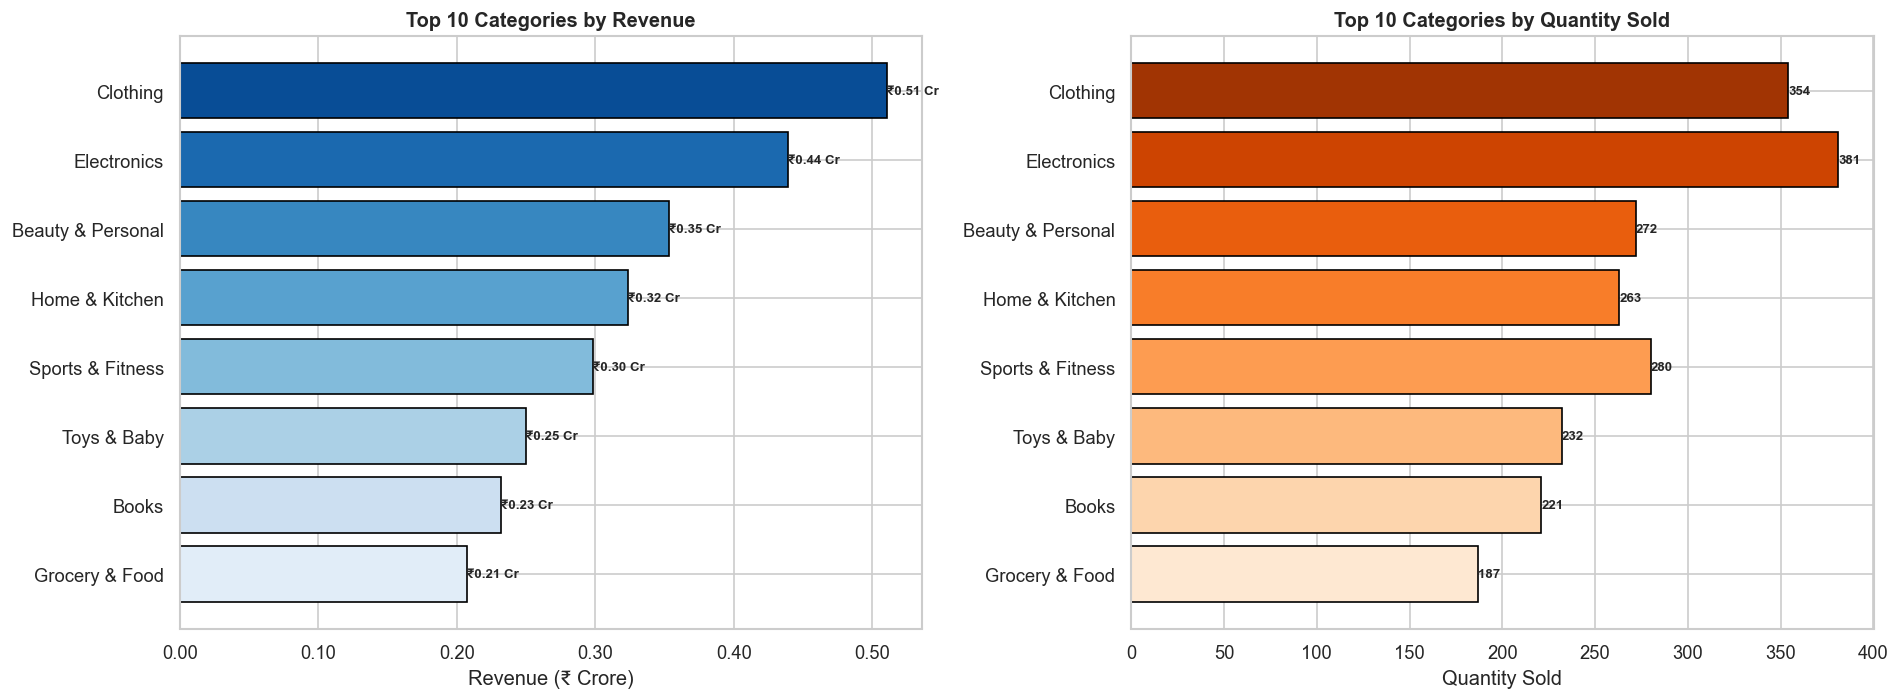

,Category,Revenue,Qty Sold,Orders,Avg Selling Price,Unique Products
2,Clothing,5103515.11,354,130,13803.876324,121
3,Electronics,4390681.14,381,142,11722.707200,136
0,Beauty & Personal,3528622.80,272,101,13145.683619,94
5,Home & Kitchen,3233724.70,263,110,12104.463063,103
6,Sports & Fitness,2982523.58,280,107,10797.472844,105
7,Toys & Baby,2496415.36,232,85,11229.946744,79
1,Books,2317776.78,221,90,10493.138041,83
4,Grocery & Food,2073166.98,187,70,11344.793239,64


In [6]:
# =========================
# Section 2: Top 10 Product Categories by Revenue & Quantity
# =========================

cat_summary = (
    item_full.groupby("product_category")
    .agg(
        total_revenue=("total_value", "sum"),
        total_qty_sold=("quantity", "sum"),
        number_of_orders=("order_id", "nunique"),
        avg_selling_price=("selling_price", "mean"),
        unique_products=("product_id", "nunique")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

top10 = cat_summary.head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars1 = axes[0].barh(
    top10["product_category"],
    top10["total_revenue"]/1e7,
    color=sns.color_palette("Blues_r", n_colors=len(top10)),
    edgecolor="black"
)
axes[0].invert_yaxis()
axes[0].set_title("Top 10 Categories by Revenue", fontweight="bold")
axes[0].set_xlabel("Revenue (\u20b9 Crore)")
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.2f}"))

for bar in bars1:
    val = bar.get_width()
    axes[0].text(val, bar.get_y() + bar.get_height()/2, f"\u20b9{val:,.2f} Cr",
                 va="center", ha="left", fontsize=8, fontweight="bold")

bars2 = axes[1].barh(
    top10["product_category"],
    top10["total_qty_sold"],
    color=sns.color_palette("Oranges_r", n_colors=len(top10)),
    edgecolor="black"
)
axes[1].invert_yaxis()
axes[1].set_title("Top 10 Categories by Quantity Sold", fontweight="bold")
axes[1].set_xlabel("Quantity Sold")
axes[1].xaxis.set_major_formatter(comma_fmt)

for bar in bars2:
    val = bar.get_width()
    axes[1].text(val, bar.get_y() + bar.get_height()/2, f"{val:,.0f}",
                 va="center", ha="left", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

display(top10.rename(columns={
    "product_category": "Category",
    "total_revenue": "Revenue",
    "total_qty_sold": "Qty Sold",
    "number_of_orders": "Orders",
    "avg_selling_price": "Avg Selling Price",
    "unique_products": "Unique Products"
}))

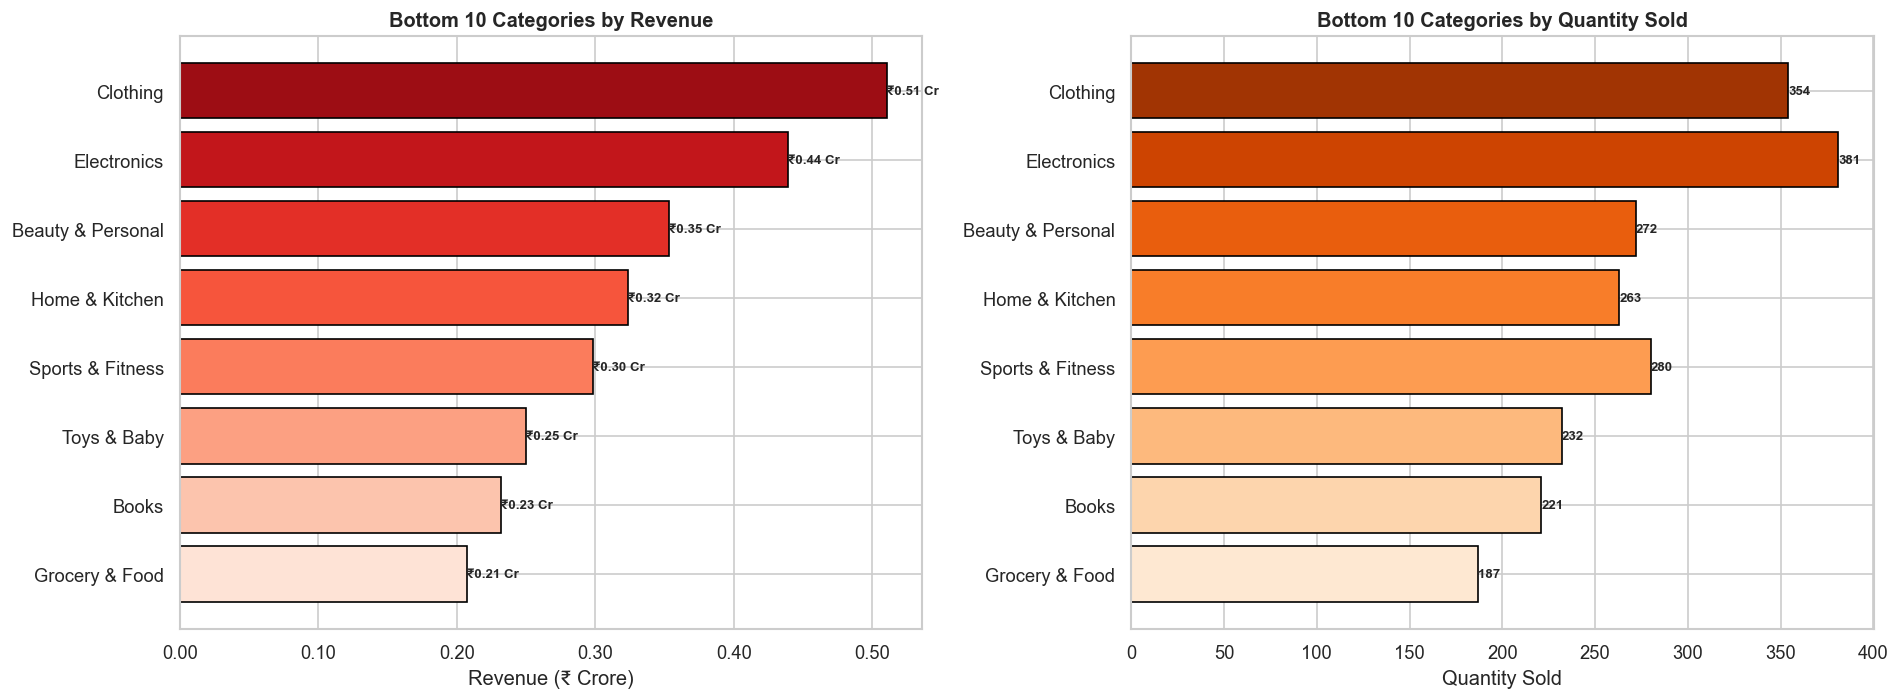

,Category,Revenue,Qty Sold,Orders,Avg Selling Price,Unique Products
4,Grocery & Food,2073166.98,187,70,11344.793239,64
1,Books,2317776.78,221,90,10493.138041,83
7,Toys & Baby,2496415.36,232,85,11229.946744,79
6,Sports & Fitness,2982523.58,280,107,10797.472844,105
5,Home & Kitchen,3233724.70,263,110,12104.463063,103
0,Beauty & Personal,3528622.80,272,101,13145.683619,94
3,Electronics,4390681.14,381,142,11722.707200,136
2,Clothing,5103515.11,354,130,13803.876324,121


In [7]:
# =========================
# Section 3: Bottom 10 Product Categories by Revenue
# =========================

bottom10 = cat_summary.tail(10).sort_values("total_revenue", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars1 = axes[0].barh(
    bottom10["product_category"],
    bottom10["total_revenue"]/1e7,
    color=sns.color_palette("Reds", n_colors=len(bottom10)),
    edgecolor="black"
)
axes[0].set_title("Bottom 10 Categories by Revenue", fontweight="bold")
axes[0].set_xlabel("Revenue (\u20b9 Crore)")
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.2f}"))

for bar in bars1:
    val = bar.get_width()
    axes[0].text(val, bar.get_y() + bar.get_height()/2, f"\u20b9{val:,.2f} Cr",
                 va="center", ha="left", fontsize=8, fontweight="bold")

bars2 = axes[1].barh(
    bottom10["product_category"],
    bottom10["total_qty_sold"],
    color=sns.color_palette("Oranges", n_colors=len(bottom10)),
    edgecolor="black"
)
axes[1].set_title("Bottom 10 Categories by Quantity Sold", fontweight="bold")
axes[1].set_xlabel("Quantity Sold")
axes[1].xaxis.set_major_formatter(comma_fmt)

for bar in bars2:
    val = bar.get_width()
    axes[1].text(val, bar.get_y() + bar.get_height()/2, f"{val:,.0f}",
                 va="center", ha="left", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

display(bottom10.rename(columns={
    "product_category": "Category",
    "total_revenue": "Revenue",
    "total_qty_sold": "Qty Sold",
    "number_of_orders": "Orders",
    "avg_selling_price": "Avg Selling Price",
    "unique_products": "Unique Products"
}))

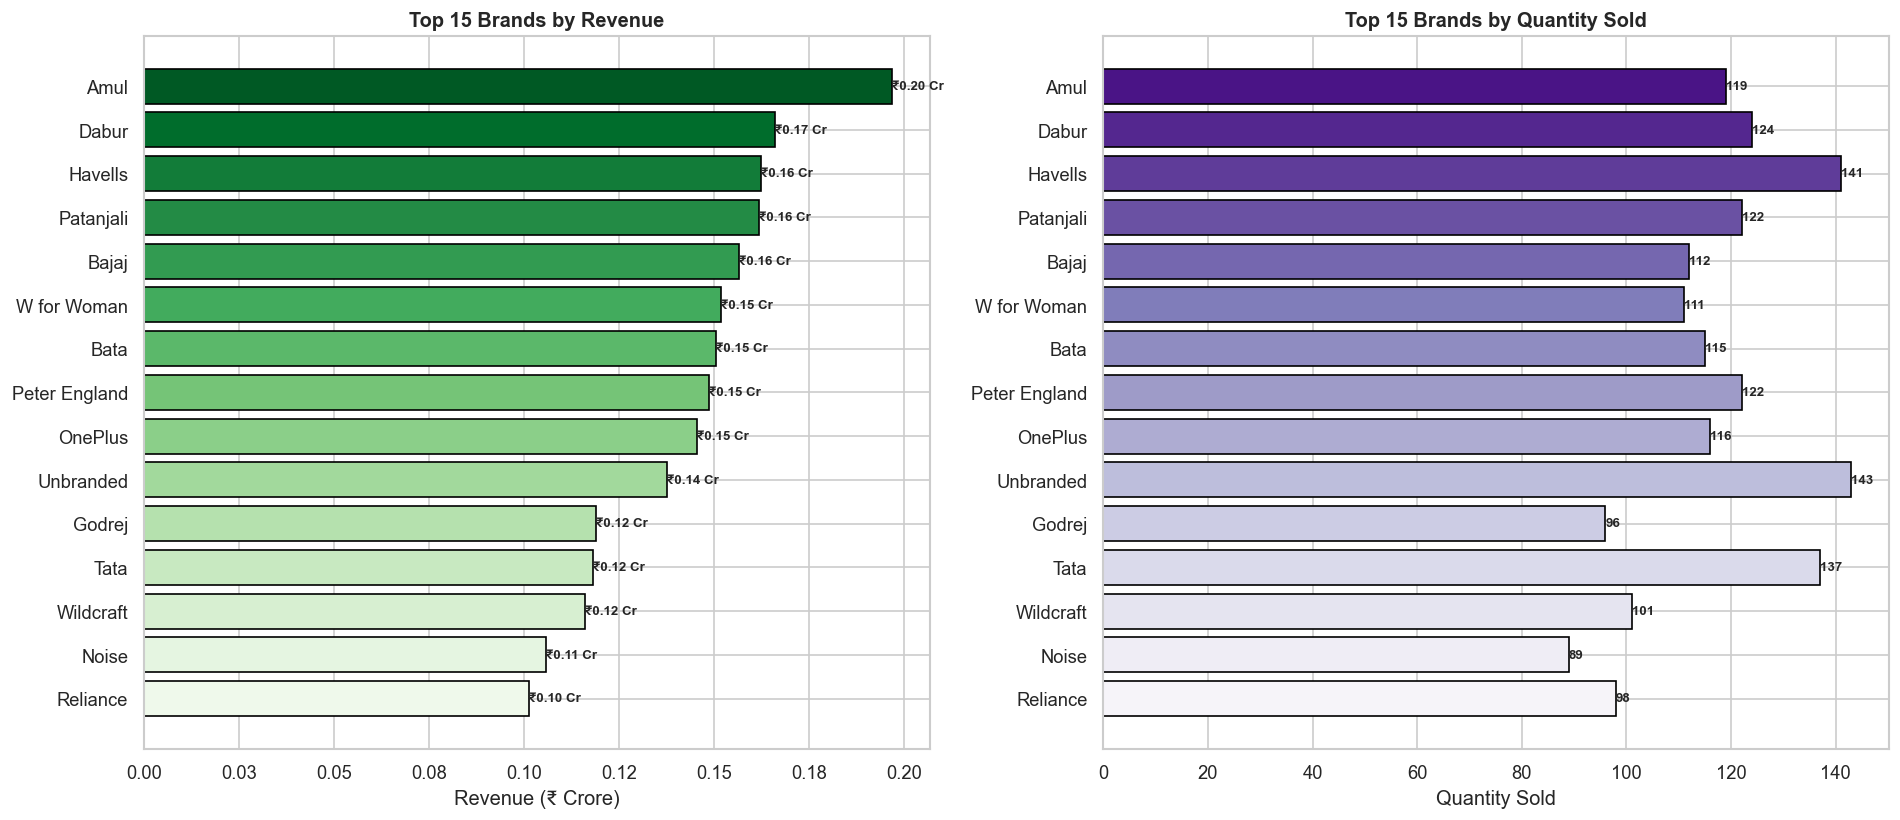

,Brand,Revenue,Qty Sold,Orders,Avg Selling Price,Unique Products
0,Amul,1968522.36,119,46,17119.138298,42
4,Dabur,1659624.37,124,49,12737.270408,42
7,Havells,1622462.92,141,50,12213.729216,46
11,Patanjali,1617169.27,122,49,13511.129388,44
1,Bajaj,1565240.12,112,42,13538.375349,39
17,W for Woman,1518011.29,111,40,13031.508810,40
2,Bata,1504757.38,115,53,12288.405660,45
12,Peter England,1485296.18,122,43,10859.480465,41
10,OnePlus,1454248.69,116,46,13075.321064,41
16,Unbranded,1374317.78,143,55,9597.044727,50


In [8]:
# =========================
# Section 4: Top 15 Brands by Revenue & Quantity
# =========================

brand_summary = (
    item_full.groupby("brand")
    .agg(
        total_revenue=("total_value", "sum"),
        total_qty_sold=("quantity", "sum"),
        number_of_orders=("order_id", "nunique"),
        avg_selling_price=("selling_price", "mean"),
        unique_products=("product_id", "nunique")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

top15_brands = brand_summary.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

bars1 = axes[0].barh(
    top15_brands["brand"],
    top15_brands["total_revenue"]/1e7,
    color=sns.color_palette("Greens_r", n_colors=len(top15_brands)),
    edgecolor="black"
)
axes[0].invert_yaxis()
axes[0].set_title("Top 15 Brands by Revenue", fontweight="bold")
axes[0].set_xlabel("Revenue (\u20b9 Crore)")
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.2f}"))

for bar in bars1:
    val = bar.get_width()
    axes[0].text(val, bar.get_y() + bar.get_height()/2, f"\u20b9{val:,.2f} Cr",
                 va="center", ha="left", fontsize=8, fontweight="bold")

bars2 = axes[1].barh(
    top15_brands["brand"],
    top15_brands["total_qty_sold"],
    color=sns.color_palette("Purples_r", n_colors=len(top15_brands)),
    edgecolor="black"
)
axes[1].invert_yaxis()
axes[1].set_title("Top 15 Brands by Quantity Sold", fontweight="bold")
axes[1].set_xlabel("Quantity Sold")
axes[1].xaxis.set_major_formatter(comma_fmt)

for bar in bars2:
    val = bar.get_width()
    axes[1].text(val, bar.get_y() + bar.get_height()/2, f"{val:,.0f}",
                 va="center", ha="left", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

display(top15_brands.rename(columns={
    "brand": "Brand",
    "total_revenue": "Revenue",
    "total_qty_sold": "Qty Sold",
    "number_of_orders": "Orders",
    "avg_selling_price": "Avg Selling Price",
    "unique_products": "Unique Products"
}))

C:\Users\richa\AppData\Local\Temp\ipykernel_34124\294724291.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


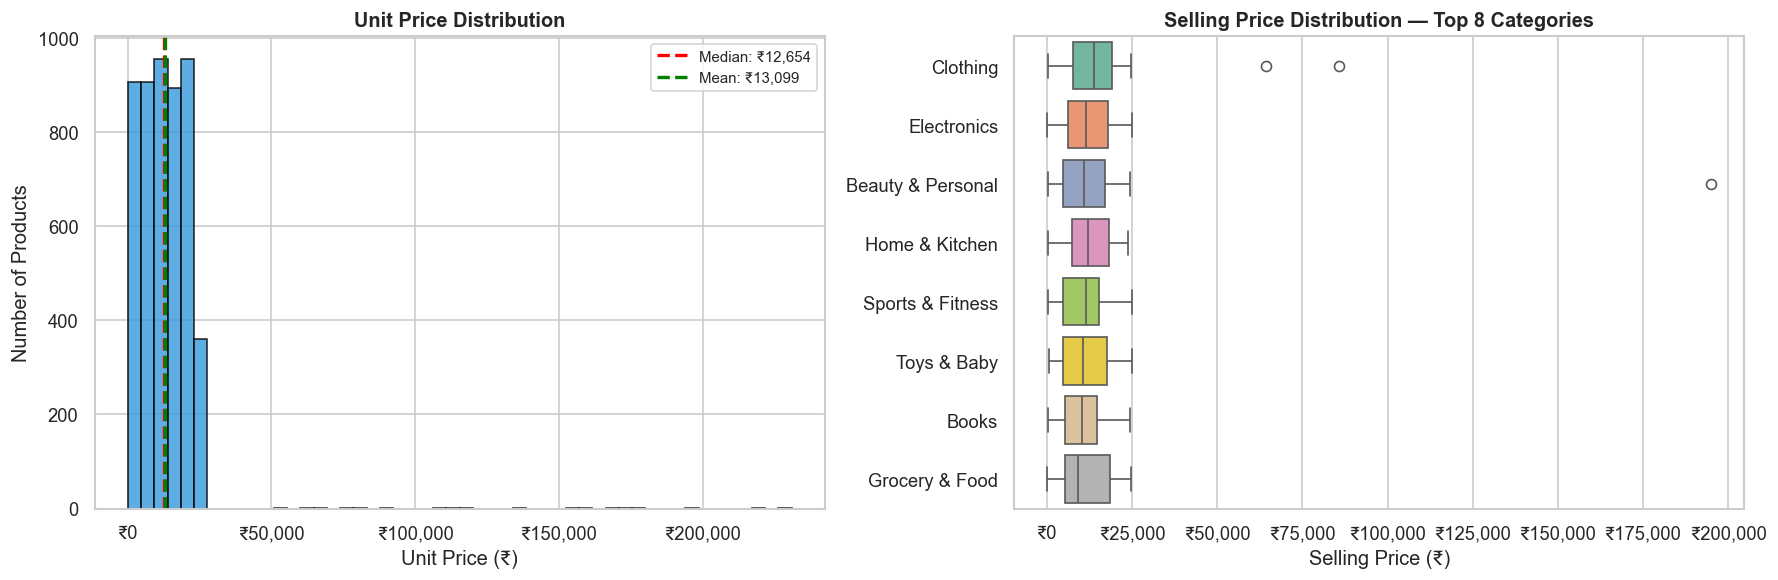

Unit Price Statistics:
  count: ₹5,000.00
  mean: ₹13,099.16
  std: ₹11,130.62
  min: ₹51.44
  25%: ₹6,288.66
  50%: ₹12,654.18
  75%: ₹18,958.97
  max: ₹230,764.96


In [9]:
# =========================
# Section 5: Product Price Distribution
# =========================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram of unit prices
axes[0].hist(products["unit_price"], bins=50, color="#3498db", edgecolor="black", alpha=0.8)
axes[0].axvline(products["unit_price"].median(), linestyle="--", color="red", linewidth=2, label=f"Median: \u20b9{products['unit_price'].median():,.0f}")
axes[0].axvline(products["unit_price"].mean(), linestyle="--", color="green", linewidth=2, label=f"Mean: \u20b9{products['unit_price'].mean():,.0f}")
axes[0].set_title("Unit Price Distribution", fontweight="bold")
axes[0].set_xlabel("Unit Price (\u20b9)")
axes[0].set_ylabel("Number of Products")
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter("\u20b9{x:,.0f}"))
axes[0].legend(fontsize=9)

# Box plot by top 8 categories
top8_cats = cat_summary.head(8)["product_category"].tolist()
price_box_data = item_full.loc[item_full["product_category"].isin(top8_cats)]

sns.boxplot(
    data=price_box_data,
    y="product_category",
    x="selling_price",
    order=top8_cats,
    palette="Set2",
    ax=axes[1]
)
axes[1].set_title("Selling Price Distribution \u2014 Top 8 Categories", fontweight="bold")
axes[1].set_xlabel("Selling Price (\u20b9)")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(mticker.StrMethodFormatter("\u20b9{x:,.0f}"))

plt.tight_layout()
plt.show()

price_stats = products["unit_price"].describe()
print("Unit Price Statistics:")
for stat, val in price_stats.items():
    print(f"  {stat}: \u20b9{val:,.2f}")

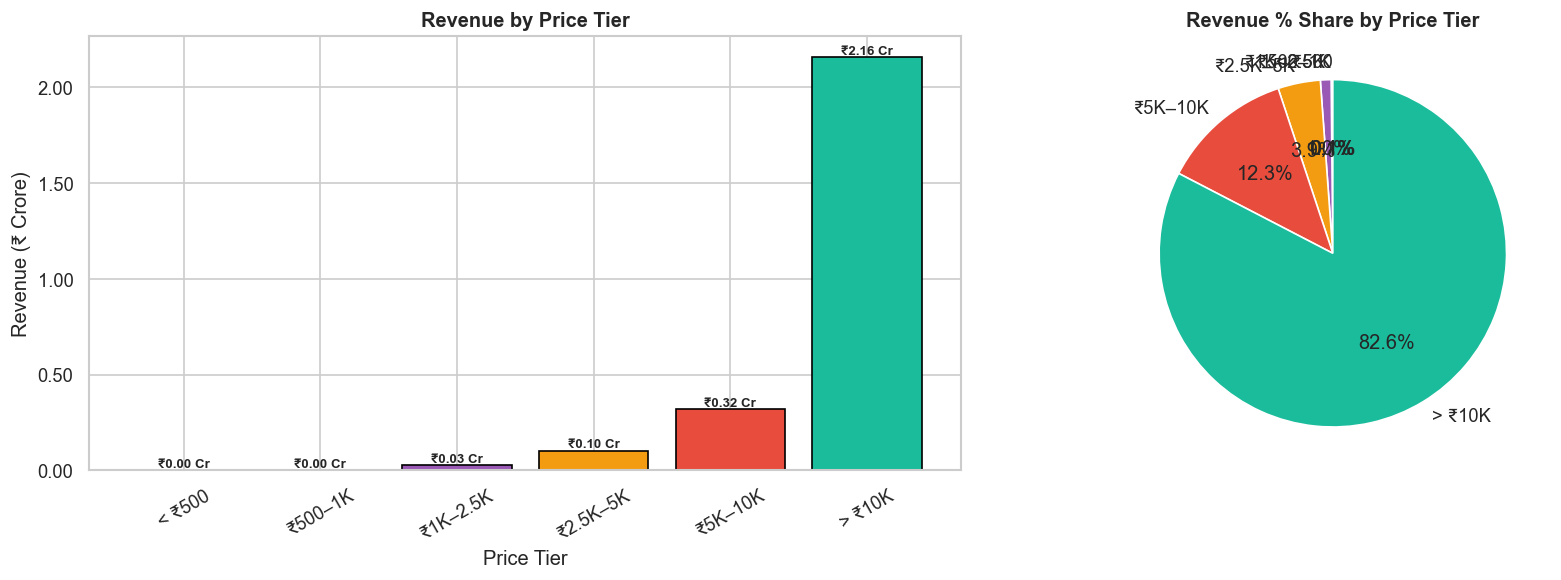

,Price Tier,Items Sold,Total Revenue,Avg Discount %,Unique Products,Revenue Share %
0,< ₹500,22,"₹15,210.07 (0.00 Cr)",7.95%,20,0.06%
1,₹500–1K,15,"₹25,708.99 (0.00 Cr)",8.00%,13,0.10%
2,₹1K–2.5K,54,"₹259,567.62 (0.03 Cr)",7.87%,50,0.99%
3,₹2.5K–5K,103,"₹1,030,922.31 (0.10 Cr)",7.33%,96,3.95%
4,₹5K–10K,177,"₹3,211,827.83 (0.32 Cr)",7.68%,162,12.29%
5,> ₹10K,494,"₹21,583,189.63 (2.16 Cr)",5.66%,449,82.61%


In [10]:
# =========================
# Section 6: Price Tier Analysis
# =========================

price_bins = [0, 500, 1000, 2500, 5000, 10000, np.inf]
price_labels = ["< \u20b9500", "\u20b9500\u20131K", "\u20b91K\u20132.5K", "\u20b92.5K\u20135K", "\u20b95K\u201310K", "> \u20b910K"]

item_full["price_tier"] = pd.cut(
    item_full["selling_price"],
    bins=price_bins,
    labels=price_labels,
    include_lowest=True,
    right=True
)

tier_summary = (
    item_full.groupby("price_tier", observed=False)
    .agg(
        number_of_items=("order_item_id", "count"),
        total_revenue=("total_value", "sum"),
        avg_discount_pct=("discount_pct", "mean"),
        unique_products=("product_id", "nunique")
    )
    .reindex(price_labels)
    .reset_index()
)

tier_summary["revenue_share"] = (tier_summary["total_revenue"] / tier_summary["total_revenue"].sum()) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors_tier = ["#2ecc71", "#3498db", "#9b59b6", "#f39c12", "#e74c3c", "#1abc9c"]

bars = axes[0].bar(
    tier_summary["price_tier"].astype(str),
    tier_summary["total_revenue"]/1e7,
    color=colors_tier,
    edgecolor="black"
)
axes[0].set_title("Revenue by Price Tier", fontweight="bold")
axes[0].set_xlabel("Price Tier")
axes[0].set_ylabel("Revenue (\u20b9 Crore)")
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.2f}"))
axes[0].tick_params(axis="x", rotation=30)

for bar in bars:
    val = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, val, f"\u20b9{val:,.2f} Cr",
                 ha="center", va="bottom", fontsize=8, fontweight="bold")

axes[1].pie(
    tier_summary["total_revenue"],
    labels=tier_summary["price_tier"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors_tier,
    wedgeprops={"edgecolor": "white"}
)
axes[1].set_title("Revenue % Share by Price Tier", fontweight="bold")

plt.tight_layout()
plt.show()

tier_display = tier_summary.copy()
tier_display["total_revenue"] = tier_display["total_revenue"].map(lambda x: f"\u20b9{x:,.2f} ({x/1e7:,.2f} Cr)")
tier_display["avg_discount_pct"] = tier_display["avg_discount_pct"].map(lambda x: f"{x:,.2f}%")
tier_display["revenue_share"] = tier_display["revenue_share"].map(lambda x: f"{x:,.2f}%")
display(tier_display.rename(columns={
    "price_tier": "Price Tier",
    "number_of_items": "Items Sold",
    "total_revenue": "Total Revenue",
    "avg_discount_pct": "Avg Discount %",
    "unique_products": "Unique Products",
    "revenue_share": "Revenue Share %"
}))

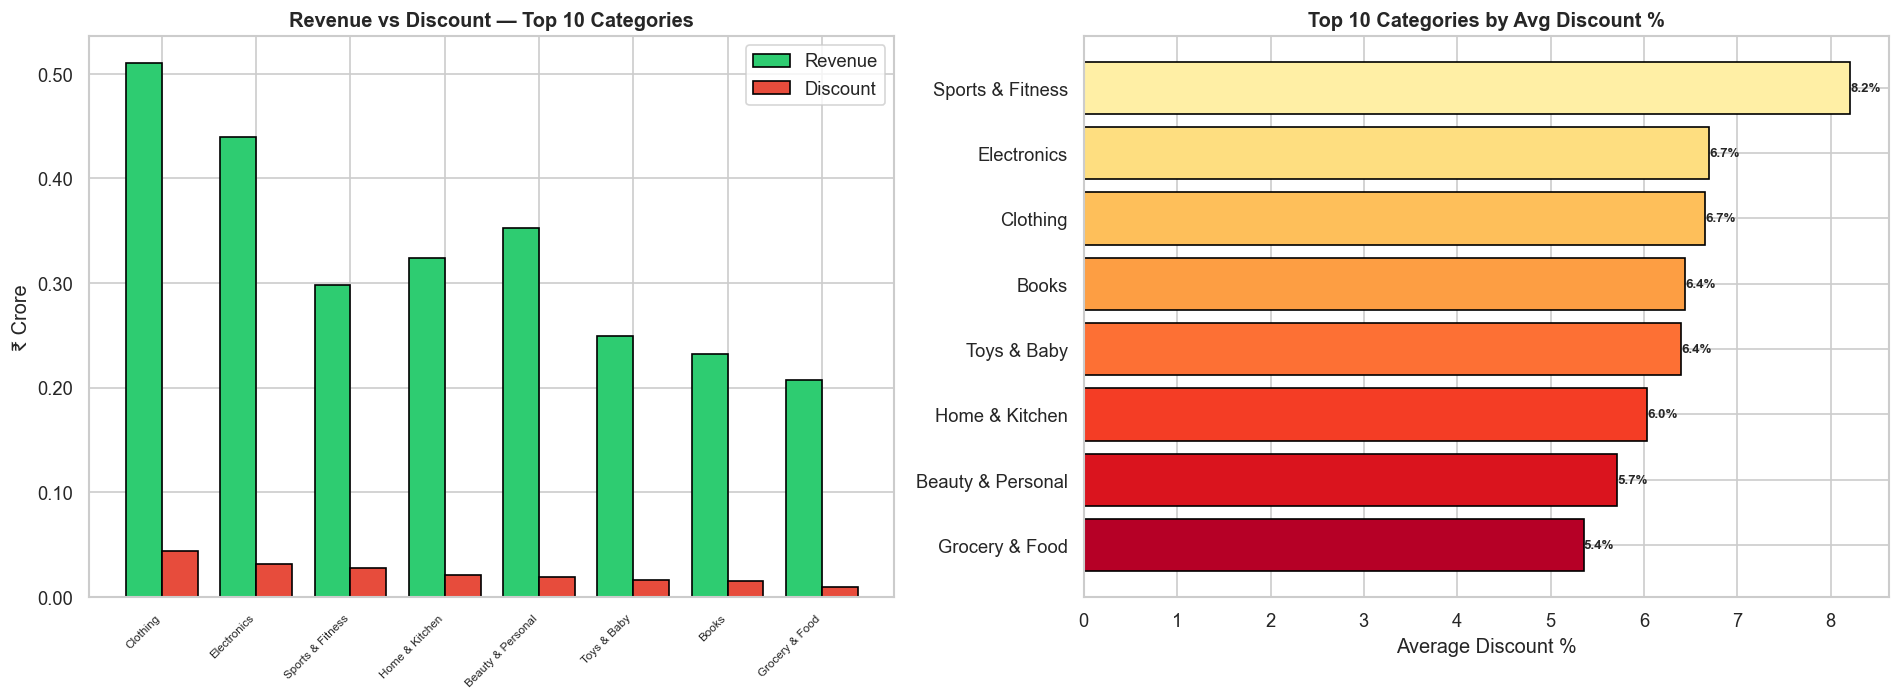

,Category,Total Revenue,Total Discount,Avg Discount %
2,Clothing,"₹5,103,515.11 (0.51 Cr)","₹435,009.15 (0.04 Cr)",6.65%
3,Electronics,"₹4,390,681.14 (0.44 Cr)","₹310,831.24 (0.03 Cr)",6.70%
6,Sports & Fitness,"₹2,982,523.58 (0.30 Cr)","₹271,236.32 (0.03 Cr)",8.21%
5,Home & Kitchen,"₹3,233,724.70 (0.32 Cr)","₹210,618.56 (0.02 Cr)",6.04%
0,Beauty & Personal,"₹3,528,622.80 (0.35 Cr)","₹186,341.57 (0.02 Cr)",5.71%
7,Toys & Baby,"₹2,496,415.36 (0.25 Cr)","₹161,956.49 (0.02 Cr)",6.40%
1,Books,"₹2,317,776.78 (0.23 Cr)","₹153,729.99 (0.02 Cr)",6.44%
4,Grocery & Food,"₹2,073,166.98 (0.21 Cr)","₹97,769.25 (0.01 Cr)",5.35%


In [11]:
# =========================
# Section 7: Discount Impact by Product Category
# =========================

item_full["discount_amount"] = (item_full["unit_price"] - item_full["selling_price"]) * item_full["quantity"]

cat_discount = (
    item_full.groupby("product_category")
    .agg(
        total_revenue=("total_value", "sum"),
        total_discount=("discount_amount", "sum"),
        avg_discount_pct=("discount_pct", "mean")
    )
    .reset_index()
    .sort_values("total_discount", ascending=False)
)

top10_disc = cat_discount.head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(top10_disc))
w = 0.38
rev_bars = axes[0].bar(x - w/2, top10_disc["total_revenue"]/1e7, width=w, color="#2ecc71", edgecolor="black", label="Revenue")
dis_bars = axes[0].bar(x + w/2, top10_disc["total_discount"]/1e7, width=w, color="#e74c3c", edgecolor="black", label="Discount")
axes[0].set_xticks(x)
axes[0].set_xticklabels(top10_disc["product_category"], rotation=45, ha="right", fontsize=7)
axes[0].set_title("Revenue vs Discount \u2014 Top 10 Categories", fontweight="bold")
axes[0].set_ylabel("\u20b9 Crore")
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.2f}"))
axes[0].legend()

# Avg discount % by category
top10_avg_disc = cat_discount.sort_values("avg_discount_pct", ascending=False).head(10)
bars = axes[1].barh(
    top10_avg_disc["product_category"],
    top10_avg_disc["avg_discount_pct"],
    color=sns.color_palette("YlOrRd", n_colors=len(top10_avg_disc)),
    edgecolor="black"
)
axes[1].invert_yaxis()
axes[1].set_title("Top 10 Categories by Avg Discount %", fontweight="bold")
axes[1].set_xlabel("Average Discount %")

for bar in bars:
    val = bar.get_width()
    axes[1].text(val, bar.get_y() + bar.get_height()/2, f"{val:,.1f}%",
                 va="center", ha="left", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

cat_disc_display = cat_discount.head(15).copy()
cat_disc_display["total_revenue"] = cat_disc_display["total_revenue"].map(lambda x: f"\u20b9{x:,.2f} ({x/1e7:,.2f} Cr)")
cat_disc_display["total_discount"] = cat_disc_display["total_discount"].map(lambda x: f"\u20b9{x:,.2f} ({x/1e7:,.2f} Cr)")
cat_disc_display["avg_discount_pct"] = cat_disc_display["avg_discount_pct"].map(lambda x: f"{x:,.2f}%")
display(cat_disc_display.rename(columns={
    "product_category": "Category",
    "total_revenue": "Total Revenue",
    "total_discount": "Total Discount",
    "avg_discount_pct": "Avg Discount %"
}))

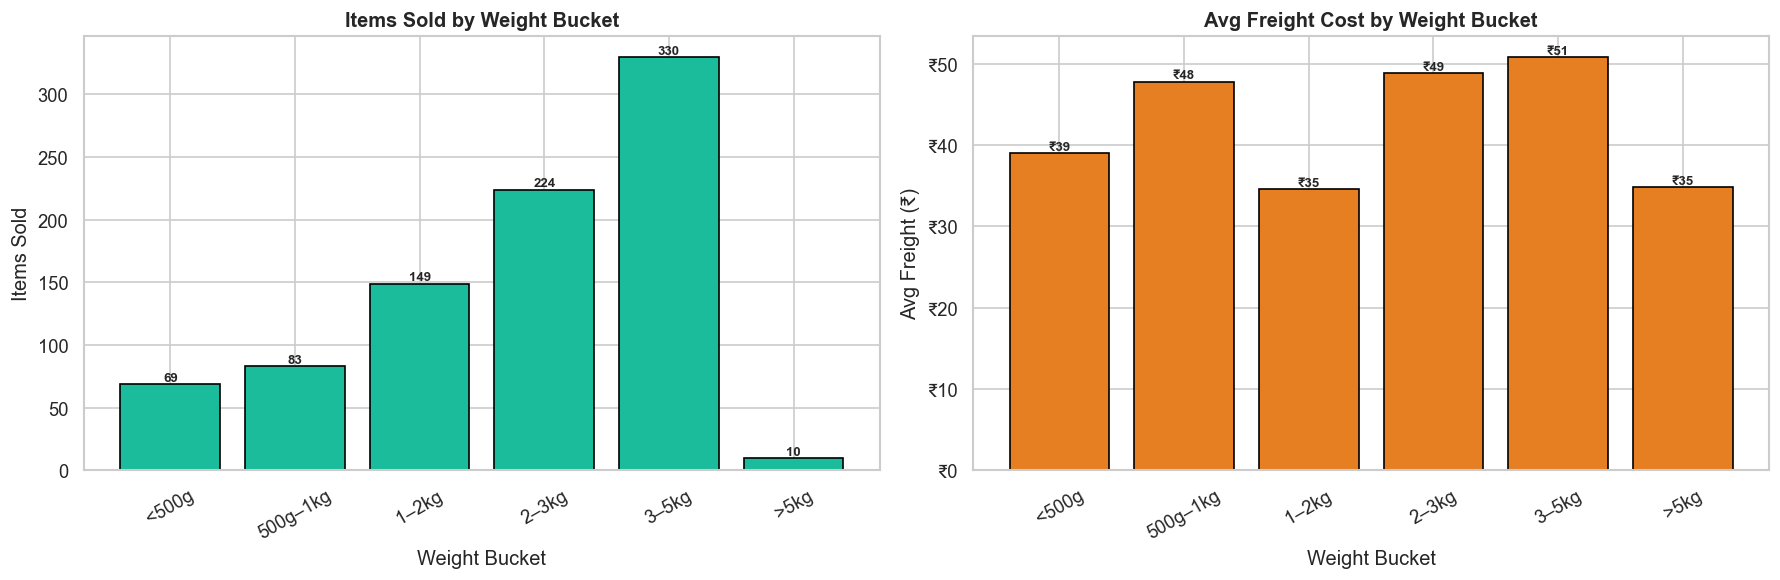

,Weight Bucket,Items Sold,Total Revenue,Avg Freight,Avg Selling Price
0,<500g,69,"₹1,801,090.83 (0.18 Cr)",₹38.98,"₹10,531.84"
1,500g–1kg,83,"₹2,653,604.39 (0.27 Cr)",₹47.80,"₹12,664.54"
2,1–2kg,149,"₹4,504,272.88 (0.45 Cr)",₹34.62,"₹11,264.18"
3,2–3kg,224,"₹7,334,268.27 (0.73 Cr)",₹48.87,"₹12,948.46"
4,3–5kg,330,"₹9,585,054.78 (0.96 Cr)",₹50.85,"₹11,710.47"
5,>5kg,10,"₹248,135.30 (0.02 Cr)",₹34.80,"₹10,451.45"


In [12]:
# =========================
# Section 8: Product Weight Analysis
# =========================

weight_bins = [0, 500, 1000, 2000, 3000, 5000, np.inf]
weight_labels = ["<500g", "500g\u20131kg", "1\u20132kg", "2\u20133kg", "3\u20135kg", ">5kg"]

item_full["weight_bucket"] = pd.cut(
    item_full["weight_grams"],
    bins=weight_bins,
    labels=weight_labels,
    include_lowest=True,
    right=True
)

weight_summary = (
    item_full.groupby("weight_bucket", observed=False)
    .agg(
        number_of_items=("order_item_id", "count"),
        total_revenue=("total_value", "sum"),
        avg_freight=("freight_value", "mean"),
        avg_selling_price=("selling_price", "mean")
    )
    .reindex(weight_labels)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bars1 = axes[0].bar(
    weight_summary["weight_bucket"].astype(str),
    weight_summary["number_of_items"],
    color="#1abc9c", edgecolor="black"
)
axes[0].set_title("Items Sold by Weight Bucket", fontweight="bold")
axes[0].set_xlabel("Weight Bucket")
axes[0].set_ylabel("Items Sold")
axes[0].yaxis.set_major_formatter(comma_fmt)
axes[0].tick_params(axis="x", rotation=30)

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f"{bar.get_height():,.0f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

# Avg freight by weight bucket
bars2 = axes[1].bar(
    weight_summary["weight_bucket"].astype(str),
    weight_summary["avg_freight"],
    color="#e67e22", edgecolor="black"
)
axes[1].set_title("Avg Freight Cost by Weight Bucket", fontweight="bold")
axes[1].set_xlabel("Weight Bucket")
axes[1].set_ylabel("Avg Freight (\u20b9)")
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter("\u20b9{x:,.0f}"))
axes[1].tick_params(axis="x", rotation=30)

for bar in bars2:
    val = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, val, f"\u20b9{val:,.0f}",
                 ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

weight_display = weight_summary.copy()
weight_display["total_revenue"] = weight_display["total_revenue"].map(lambda x: f"\u20b9{x:,.2f} ({x/1e7:,.2f} Cr)")
weight_display["avg_freight"] = weight_display["avg_freight"].map(lambda x: f"\u20b9{x:,.2f}")
weight_display["avg_selling_price"] = weight_display["avg_selling_price"].map(lambda x: f"\u20b9{x:,.2f}")
display(weight_display.rename(columns={
    "weight_bucket": "Weight Bucket",
    "number_of_items": "Items Sold",
    "total_revenue": "Total Revenue",
    "avg_freight": "Avg Freight",
    "avg_selling_price": "Avg Selling Price"
}))

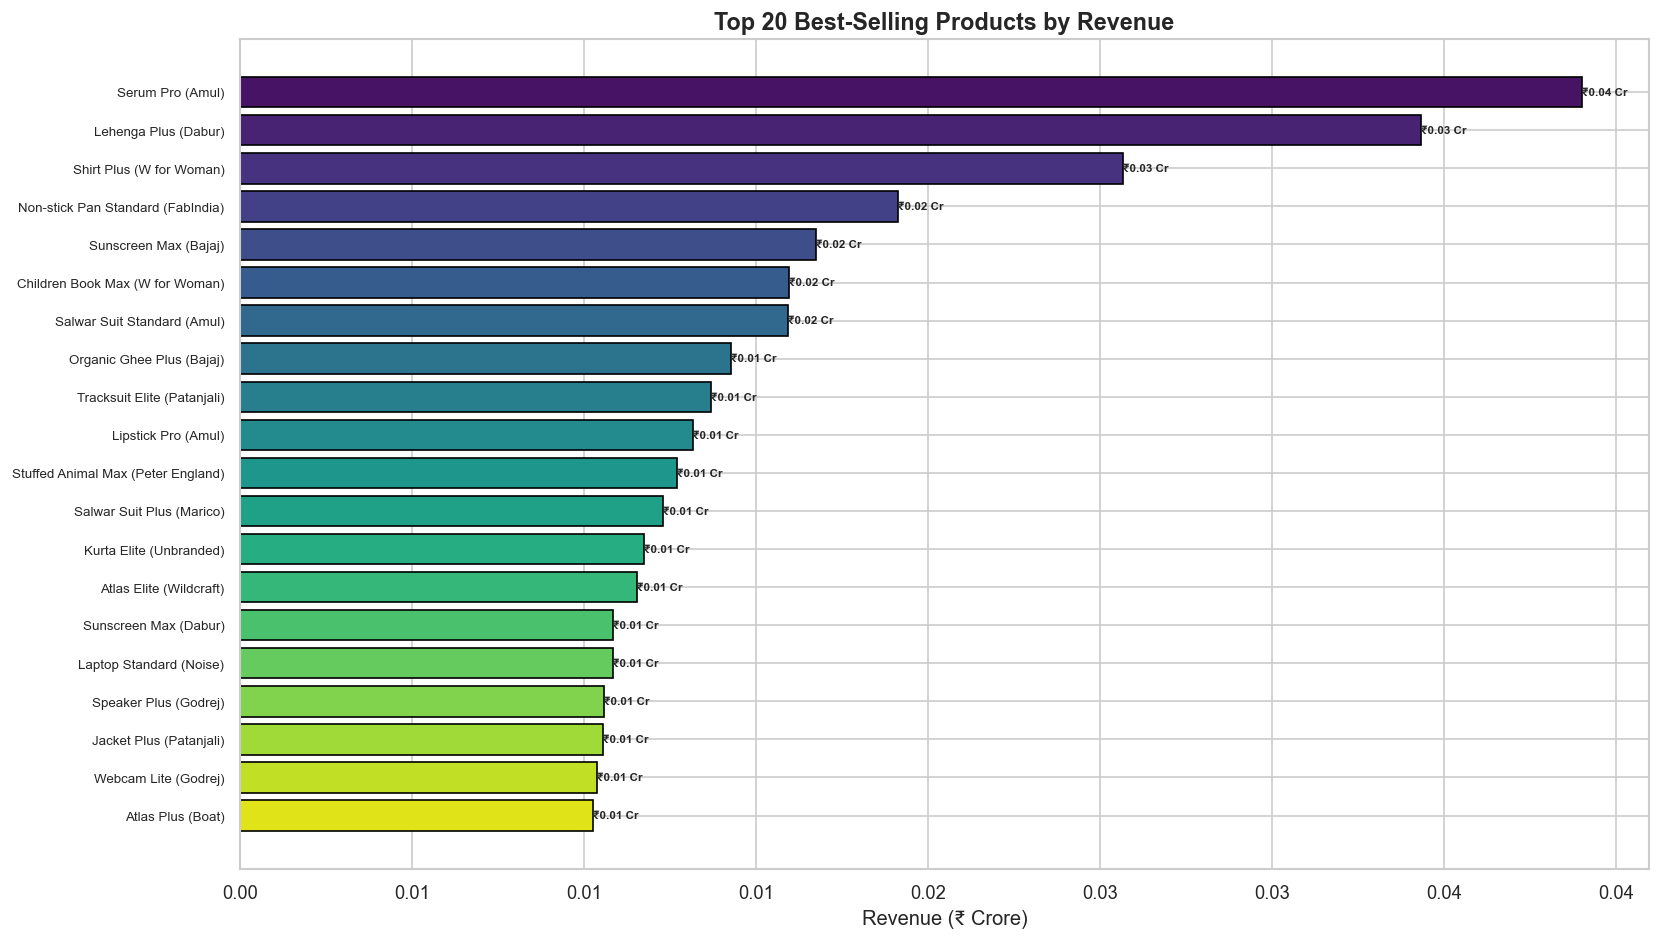

,Product,Brand,Category,Revenue,Qty Sold,Orders,Avg Price
10,Serum Pro,Amul,Beauty & Personal,"₹390,106.46 (0.04 Cr)",2,1,"₹194,981.30"
21,Lehenga Plus,Dabur,Clothing,"₹343,254.48 (0.03 Cr)",4,1,"₹85,813.62"
424,Shirt Plus,W for Woman,Clothing,"₹256,675.00 (0.03 Cr)",4,1,"₹64,168.75"
724,Non-stick Pan Standard,FabIndia,Home & Kitchen,"₹191,209.50 (0.02 Cr)",8,2,"₹23,881.54"
458,Sunscreen Max,Bajaj,Beauty & Personal,"₹167,578.84 (0.02 Cr)",8,2,"₹20,946.15"
189,Children Book Max,W for Woman,Books,"₹159,725.76 (0.02 Cr)",8,1,"₹19,965.72"
212,Salwar Suit Standard,Amul,Clothing,"₹159,174.12 (0.02 Cr)",8,2,"₹19,892.30"
448,Organic Ghee Plus,Bajaj,Grocery & Food,"₹142,771.44 (0.01 Cr)",8,2,"₹17,846.43"
257,Tracksuit Elite,Patanjali,Clothing,"₹136,764.56 (0.01 Cr)",6,2,"₹22,784.45"
346,Lipstick Pro,Amul,Beauty & Personal,"₹131,627.56 (0.01 Cr)",6,2,"₹21,896.60"


In [13]:
# =========================
# Section 9: Top 20 Best-Selling Products
# =========================

product_sales = (
    item_full.groupby(["product_id", "product_name", "product_category", "brand"])
    .agg(
        total_revenue=("total_value", "sum"),
        total_qty_sold=("quantity", "sum"),
        number_of_orders=("order_id", "nunique"),
        avg_selling_price=("selling_price", "mean")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

top20 = product_sales.head(20)

fig, ax = plt.subplots(figsize=(14, 8))

labels = top20["product_name"] + " (" + top20["brand"] + ")"
bars = ax.barh(
    labels,
    top20["total_revenue"]/1e7,
    color=sns.color_palette("viridis", n_colors=len(top20)),
    edgecolor="black"
)
ax.invert_yaxis()
ax.set_title("Top 20 Best-Selling Products by Revenue", fontsize=14, fontweight="bold")
ax.set_xlabel("Revenue (\u20b9 Crore)")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.2f}"))
ax.tick_params(axis="y", labelsize=8)

for bar in bars:
    val = bar.get_width()
    ax.text(val, bar.get_y() + bar.get_height()/2, f"\u20b9{val:,.2f} Cr",
             va="center", ha="left", fontsize=7, fontweight="bold")

plt.tight_layout()
plt.show()

top20_display = top20.copy()
top20_display["total_revenue"] = top20_display["total_revenue"].map(lambda x: f"\u20b9{x:,.2f} ({x/1e7:,.2f} Cr)")
top20_display["avg_selling_price"] = top20_display["avg_selling_price"].map(lambda x: f"\u20b9{x:,.2f}")
display(top20_display[["product_name", "brand", "product_category", "total_revenue", "total_qty_sold", "number_of_orders", "avg_selling_price"]].rename(columns={
    "product_name": "Product",
    "brand": "Brand",
    "product_category": "Category",
    "total_revenue": "Revenue",
    "total_qty_sold": "Qty Sold",
    "number_of_orders": "Orders",
    "avg_selling_price": "Avg Price"
}))

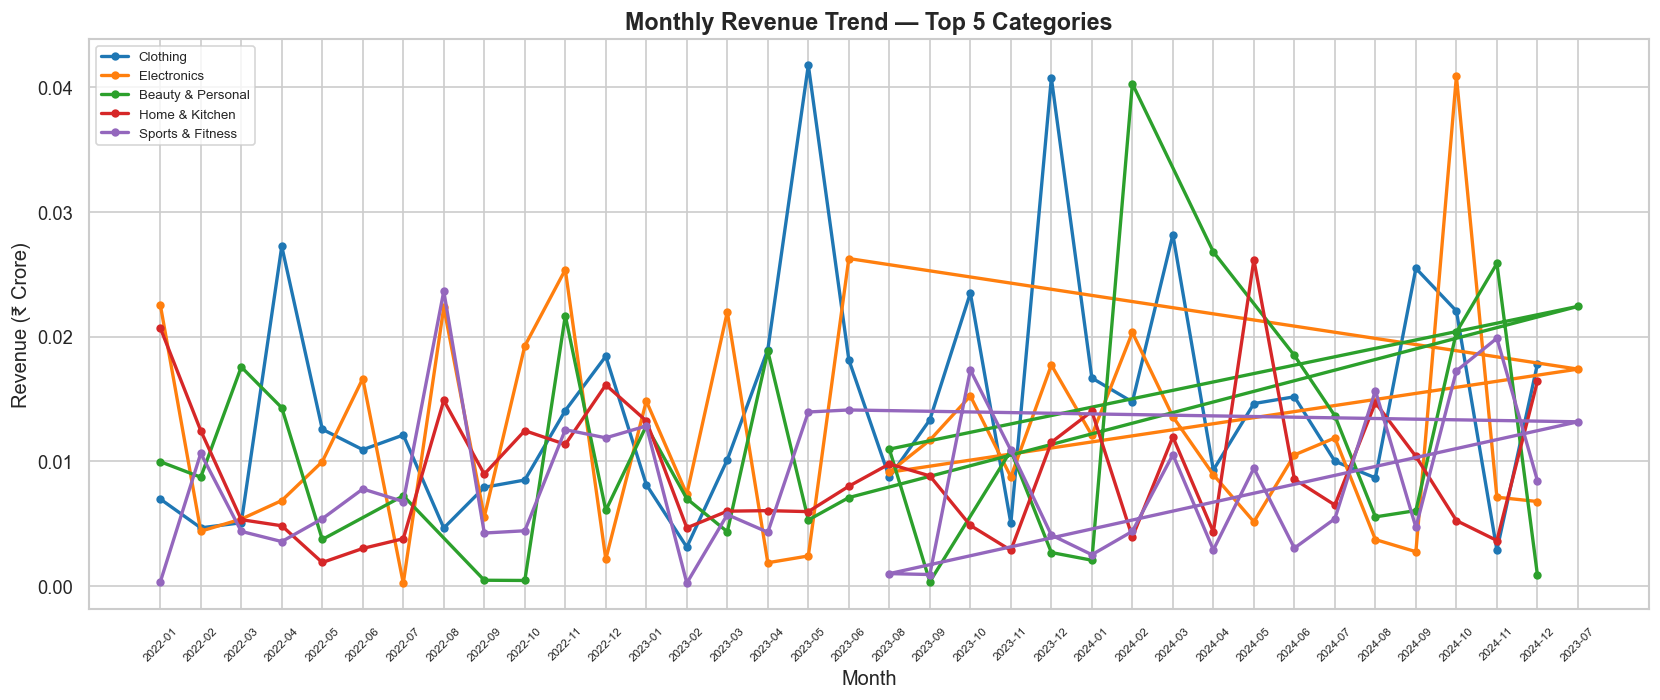

In [14]:
# =========================
# Section 10: Category Revenue Trend (Monthly)
# =========================

delivered_ts = orders.loc[orders["order_status"].eq("delivered"), ["order_id", "order_purchase_timestamp"]].copy()
delivered_ts["order_purchase_timestamp"] = pd.to_datetime(
    delivered_ts["order_purchase_timestamp"], format="mixed", errors="coerce"
)
delivered_ts["month"] = delivered_ts["order_purchase_timestamp"].dt.to_period("M")

item_monthly = (
    order_items.merge(delivered_ts, on="order_id", how="inner")
    .merge(products[["product_id", "product_category"]], on="product_id", how="left")
)

# Top 5 categories for trend
top5_cats = cat_summary.head(5)["product_category"].tolist()
item_monthly_top5 = item_monthly.loc[item_monthly["product_category"].isin(top5_cats)]

monthly_cat = (
    item_monthly_top5.groupby(["month", "product_category"])
    .agg(monthly_revenue=("total_value", "sum"))
    .reset_index()
    .sort_values("month")
)

monthly_cat["month_str"] = monthly_cat["month"].astype(str)

fig, ax = plt.subplots(figsize=(14, 6))

palette = sns.color_palette("tab10", n_colors=5)
for i, cat in enumerate(top5_cats):
    cat_data = monthly_cat.loc[monthly_cat["product_category"].eq(cat)]
    ax.plot(cat_data["month_str"], cat_data["monthly_revenue"]/1e7,
            marker="o", linewidth=2, label=cat, color=palette[i], markersize=4)

ax.set_title("Monthly Revenue Trend \u2014 Top 5 Categories", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (\u20b9 Crore)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.2f}"))
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

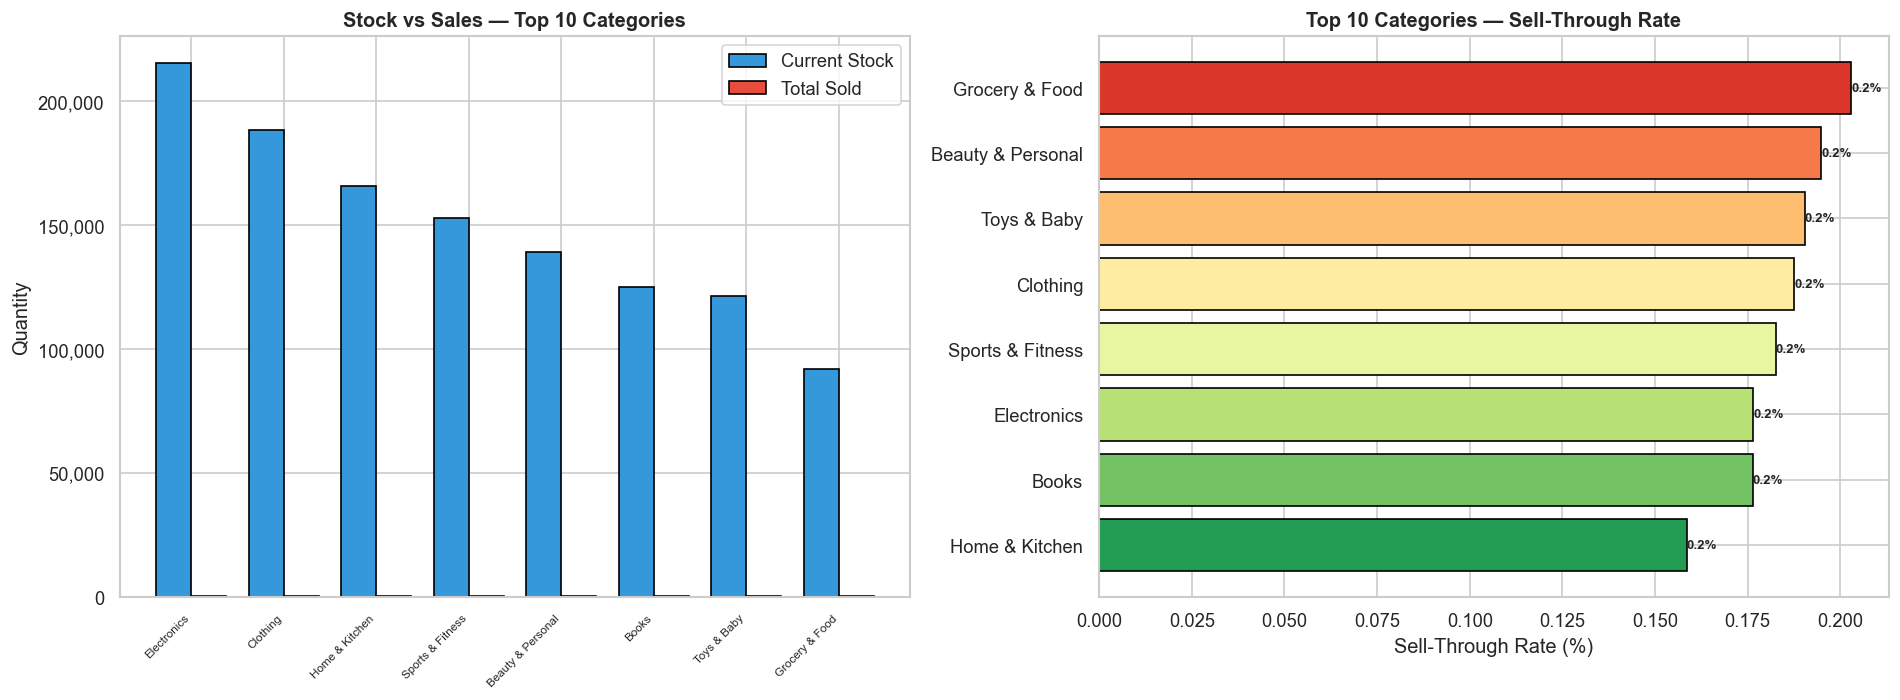


Products Never Sold: 4,215 out of 5,000 (84.3%)
Dead Stock Value (at unit price): ₹13,217,560,747.17 (1,321.76 Cr)


,Category,Current Stock,Total Sold,Products,Sell-Through %
3,Electronics,215587,381,907,0.176415
2,Clothing,188437,354,774,0.187509
5,Home & Kitchen,165693,263,707,0.158476
6,Sports & Fitness,153124,280,632,0.182525
0,Beauty & Personal,139330,272,567,0.194840
1,Books,125074,221,516,0.176384
7,Toys & Baby,121644,232,509,0.190357
4,Grocery & Food,91978,187,388,0.202897


In [15]:
# =========================
# Section 11: Stock Inventory Analysis
# =========================

# Merge stock info with sales
product_stock = (
    products[["product_id", "product_name", "product_category", "brand", "stock_qty", "unit_price"]]
    .merge(
        item_full.groupby("product_id").agg(total_sold=("quantity", "sum")).reset_index(),
        on="product_id",
        how="left"
    )
)
product_stock["total_sold"] = product_stock["total_sold"].fillna(0).astype(int)
product_stock["stock_to_sales_ratio"] = np.where(
    product_stock["total_sold"] > 0,
    product_stock["stock_qty"] / product_stock["total_sold"],
    np.inf
)

# Category-level stock summary
cat_stock = (
    product_stock.groupby("product_category")
    .agg(
        total_stock=("stock_qty", "sum"),
        total_sold=("total_sold", "sum"),
        num_products=("product_id", "nunique")
    )
    .reset_index()
    .sort_values("total_stock", ascending=False)
)

cat_stock["sell_through_rate"] = (cat_stock["total_sold"] / (cat_stock["total_stock"] + cat_stock["total_sold"])) * 100

top10_stock = cat_stock.head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(top10_stock))
w = 0.38
b1 = axes[0].bar(x - w/2, top10_stock["total_stock"], width=w, color="#3498db", edgecolor="black", label="Current Stock")
b2 = axes[0].bar(x + w/2, top10_stock["total_sold"], width=w, color="#e74c3c", edgecolor="black", label="Total Sold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(top10_stock["product_category"], rotation=45, ha="right", fontsize=7)
axes[0].set_title("Stock vs Sales \u2014 Top 10 Categories", fontweight="bold")
axes[0].set_ylabel("Quantity")
axes[0].yaxis.set_major_formatter(comma_fmt)
axes[0].legend()

# Sell-through rate
sorted_str = cat_stock.sort_values("sell_through_rate", ascending=False).head(10)
bars = axes[1].barh(
    sorted_str["product_category"],
    sorted_str["sell_through_rate"],
    color=sns.color_palette("RdYlGn", n_colors=len(sorted_str)),
    edgecolor="black"
)
axes[1].invert_yaxis()
axes[1].set_title("Top 10 Categories \u2014 Sell-Through Rate", fontweight="bold")
axes[1].set_xlabel("Sell-Through Rate (%)")

for bar in bars:
    val = bar.get_width()
    axes[1].text(val, bar.get_y() + bar.get_height()/2, f"{val:,.1f}%",
                 va="center", ha="left", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

# Unsold products
unsold = product_stock.loc[product_stock["total_sold"].eq(0)]
print(f"\nProducts Never Sold: {len(unsold):,} out of {len(product_stock):,} ({len(unsold)/len(product_stock)*100:.1f}%)")
print(f"Dead Stock Value (at unit price): \u20b9{(unsold['stock_qty'] * unsold['unit_price']).sum():,.2f} ({(unsold['stock_qty'] * unsold['unit_price']).sum()/1e7:,.2f} Cr)")

display(cat_stock.head(15).rename(columns={
    "product_category": "Category",
    "total_stock": "Current Stock",
    "total_sold": "Total Sold",
    "num_products": "Products",
    "sell_through_rate": "Sell-Through %"
}))

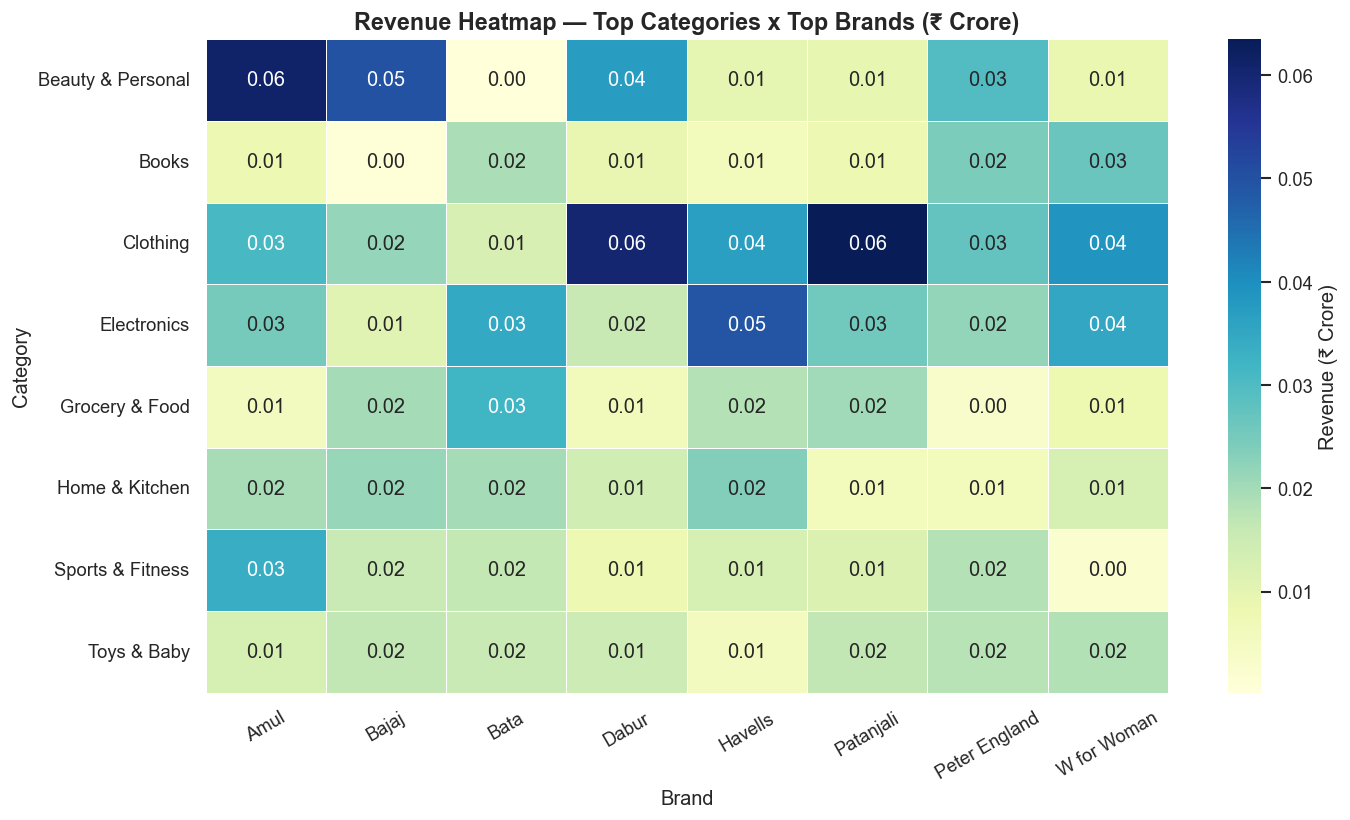

In [16]:
# =========================
# Section 12: Category x Brand Heatmap (Revenue)
# =========================

# Top 8 categories x Top 8 brands
top8_cats = cat_summary.head(8)["product_category"].tolist()
top8_brands = brand_summary.head(8)["brand"].tolist()

heatmap_data = (
    item_full
    .loc[item_full["product_category"].isin(top8_cats) & item_full["brand"].isin(top8_brands)]
    .groupby(["product_category", "brand"])["total_value"]
    .sum()
    .unstack(fill_value=0)
    / 1e7
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Revenue (\u20b9 Crore)"}
)
ax.set_title("Revenue Heatmap \u2014 Top Categories x Top Brands (\u20b9 Crore)", fontsize=14, fontweight="bold")
ax.set_xlabel("Brand")
ax.set_ylabel("Category")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Total delivered orders      : 673
Multi-category orders (2+)  : 161  (23.9%)
Single-category orders      : 512  (76.1%)


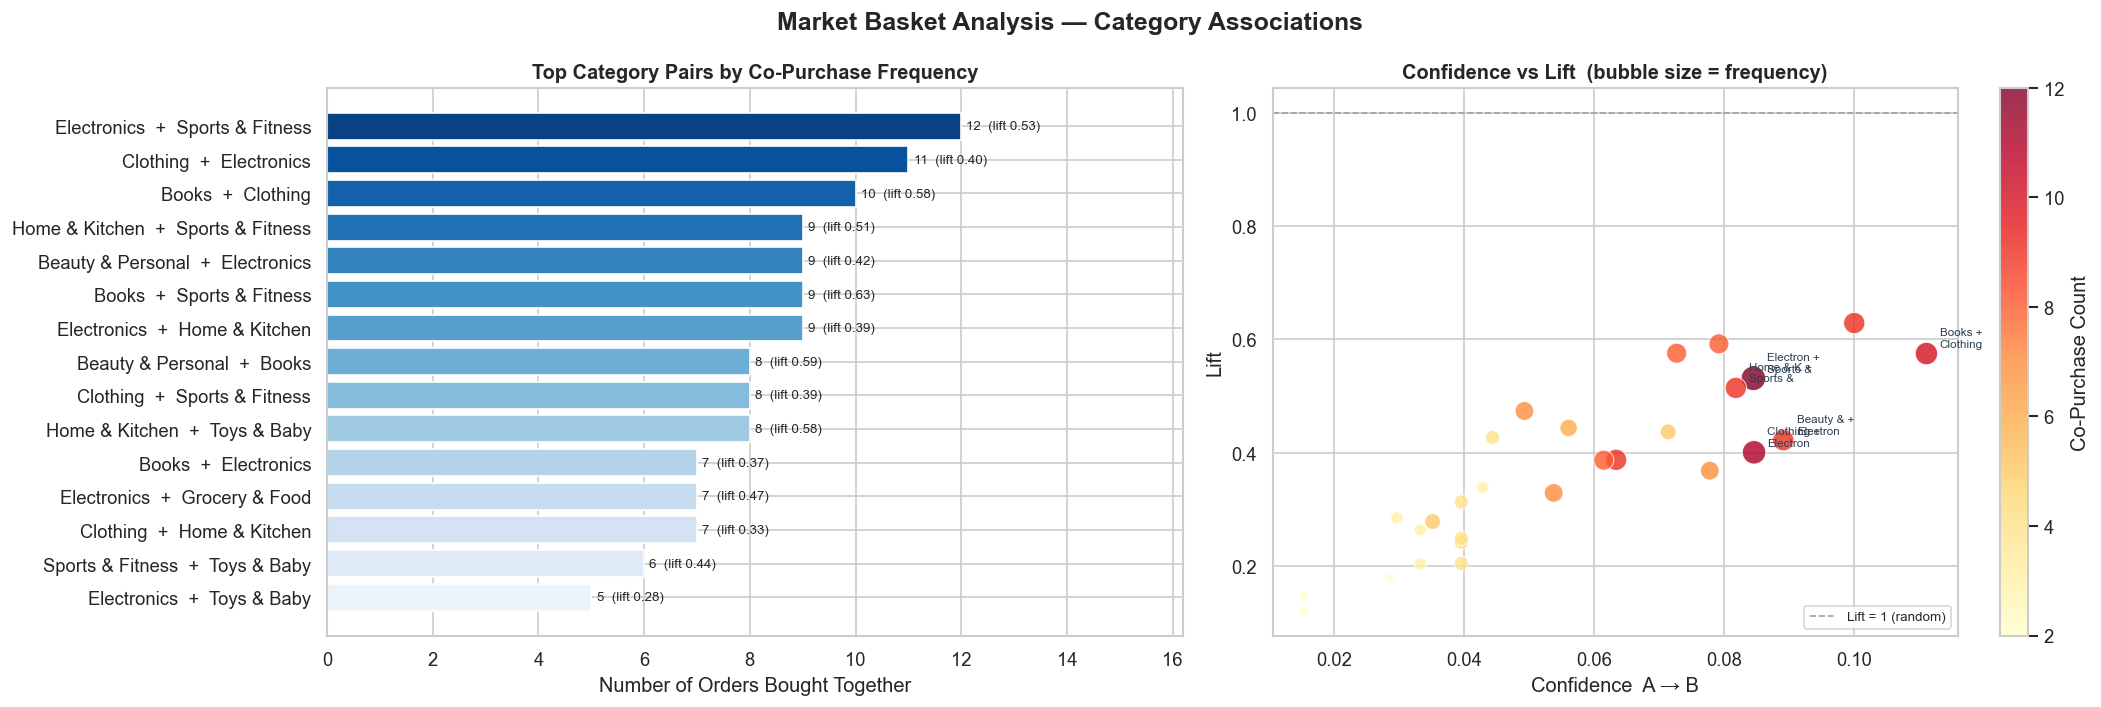

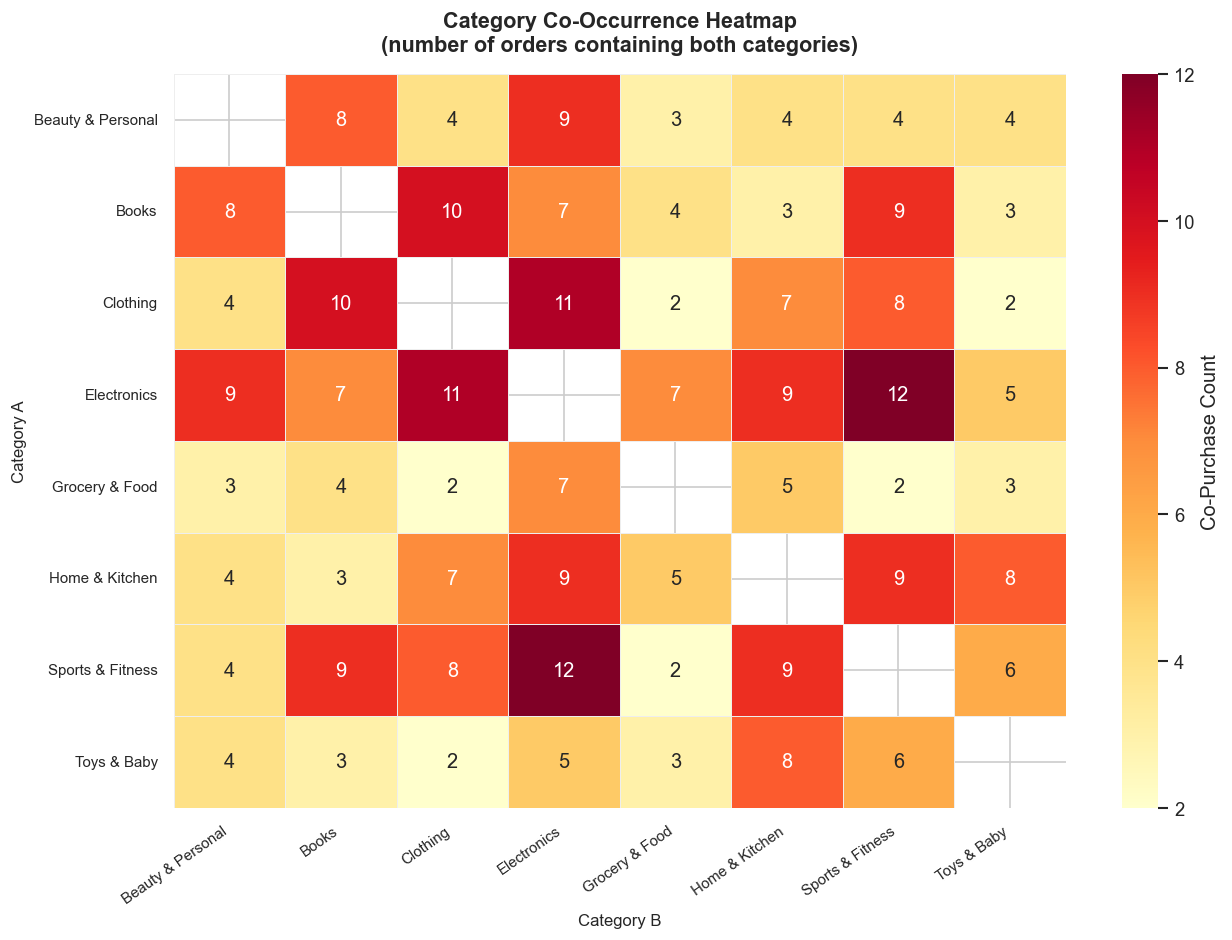

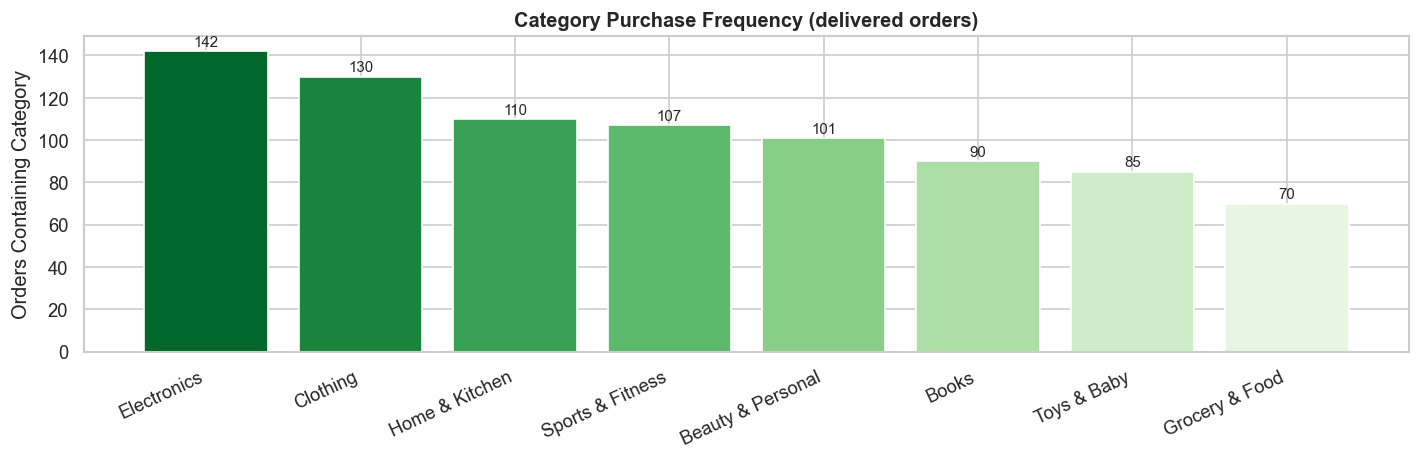


── Top Association Rules (sorted by Co-Purchases) ──
       Category A       Category B  Co-Purchases  Support  Conf A→B  Conf B→A   Lift
      Electronics Sports & Fitness            12   0.0178    0.0845    0.1121 0.5315
         Clothing      Electronics            11   0.0163    0.0846    0.0775 0.4010
            Books         Clothing            10   0.0149    0.1111    0.0769 0.5752
   Home & Kitchen Sports & Fitness             9   0.0134    0.0818    0.0841 0.5146
Beauty & Personal      Electronics             9   0.0134    0.0891    0.0634 0.4223
            Books Sports & Fitness             9   0.0134    0.1000    0.0841 0.6290
      Electronics   Home & Kitchen             9   0.0134    0.0634    0.0818 0.3878
Beauty & Personal            Books             8   0.0119    0.0792    0.0889 0.5923
         Clothing Sports & Fitness             8   0.0119    0.0615    0.0748 0.3871
   Home & Kitchen      Toys & Baby             8   0.0119    0.0727    0.0941 0.5758
           

In [18]:
# =========================
# Section 13: Market Basket Analysis (Category-Level)
# =========================

from itertools import combinations

# ── Build category baskets ────────────────────────────────────────────────────
delivered_ids = orders.loc[orders["order_status"] == "delivered", "order_id"]
items_mba = (
    order_items[order_items["order_id"].isin(delivered_ids)]
    .merge(products[["product_id", "product_category"]], on="product_id", how="left")
)

# One row per order → list of unique categories bought
cat_baskets = (
    items_mba.groupby("order_id")["product_category"]
    .apply(lambda x: sorted(x.dropna().unique().tolist()))
    .reset_index()
    .rename(columns={"product_category": "categories"})
)
multi_baskets = cat_baskets[cat_baskets["categories"].apply(len) >= 2]

total_orders    = len(delivered_ids)
multi_orders    = len(multi_baskets)
single_orders   = total_orders - multi_orders

print(f"Total delivered orders      : {total_orders:,}")
print(f"Multi-category orders (2+)  : {multi_orders:,}  ({multi_orders/total_orders*100:.1f}%)")
print(f"Single-category orders      : {single_orders:,}  ({single_orders/total_orders*100:.1f}%)")

# ── Individual category frequency ─────────────────────────────────────────────
cat_freq = {}
for cats in cat_baskets["categories"]:
    for c in cats:
        cat_freq[c] = cat_freq.get(c, 0) + 1
categories = sorted(cat_freq.keys())

# ── Pair-level association metrics ────────────────────────────────────────────
pair_counts = {}
for cats in multi_baskets["categories"]:
    for a, b in combinations(cats, 2):
        pair_counts[(a, b)] = pair_counts.get((a, b), 0) + 1

rules = []
for (a, b), cnt in pair_counts.items():
    support      = cnt / total_orders
    conf_ab      = cnt / cat_freq[a]          # P(B | A)
    conf_ba      = cnt / cat_freq[b]          # P(A | B)
    lift         = support / ((cat_freq[a] / total_orders) * (cat_freq[b] / total_orders))
    rules.append({
        "Category A":  a,
        "Category B":  b,
        "Co-Purchases": cnt,
        "Support":     round(support,  4),
        "Conf A→B":    round(conf_ab,  4),
        "Conf B→A":    round(conf_ba,  4),
        "Lift":        round(lift,     4),
    })

rules_df = pd.DataFrame(rules).sort_values("Co-Purchases", ascending=False).reset_index(drop=True)

# ── Co-occurrence matrix (for heatmap) ───────────────────────────────────────
co_matrix = pd.DataFrame(0, index=categories, columns=categories)
for (a, b), cnt in pair_counts.items():
    co_matrix.loc[a, b] = cnt
    co_matrix.loc[b, a] = cnt

# ── Figure 1 : Top pairs bar + lift scatter ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Market Basket Analysis — Category Associations", fontsize=15, fontweight="bold")

top15 = rules_df.head(15).copy()
top15["Pair"] = top15["Category A"] + "  +  " + top15["Category B"]

# Left — Top pairs by co-purchase count
ax1 = axes[0]
palette = sns.color_palette("Blues_r", len(top15))
bars = ax1.barh(top15["Pair"], top15["Co-Purchases"], color=palette)
ax1.invert_yaxis()
ax1.set_xlabel("Number of Orders Bought Together")
ax1.set_title("Top Category Pairs by Co-Purchase Frequency", fontweight="bold")
for bar, row in zip(bars, top15.itertuples()):
    ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
             f"{int(row._3)}  (lift {row.Lift:.2f})",
             va="center", fontsize=8)
ax1.set_xlim(0, top15["Co-Purchases"].max() * 1.35)

# Right — Confidence A→B vs Lift bubble chart
ax2 = axes[1]
scatter = ax2.scatter(
    rules_df["Conf A→B"],
    rules_df["Lift"],
    s=rules_df["Co-Purchases"] * 18,
    c=rules_df["Co-Purchases"],
    cmap="YlOrRd",
    alpha=0.8,
    edgecolors="white",
    linewidths=0.6,
)
plt.colorbar(scatter, ax=ax2, label="Co-Purchase Count")
ax2.set_xlabel("Confidence  A → B")
ax2.set_ylabel("Lift")
ax2.set_title("Confidence vs Lift  (bubble size = frequency)", fontweight="bold")
ax2.axhline(1.0, color="#95a5a6", linestyle="--", linewidth=1, label="Lift = 1 (random)")
ax2.legend(fontsize=8)

# Annotate top 5
for _, row in rules_df.head(5).iterrows():
    ax2.annotate(
        f"{row['Category A'][:8]} +\n{row['Category B'][:8]}",
        xy=(row["Conf A→B"], row["Lift"]),
        xytext=(8, 4), textcoords="offset points", fontsize=7, color="#2c3e50"
    )

plt.tight_layout()
plt.show()

# ── Figure 2 : Co-occurrence heatmap ─────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(11, 8))
mask = co_matrix == 0          # hide zeros
sns.heatmap(
    co_matrix, ax=ax,
    annot=True, fmt="d",
    cmap="YlOrRd",
    mask=mask,
    linewidths=0.5,
    linecolor="#eeeeee",
    cbar_kws={"label": "Co-Purchase Count"},
)
ax.set_title("Category Co-Occurrence Heatmap\n(number of orders containing both categories)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Category B", fontsize=10)
ax.set_ylabel("Category A", fontsize=10)
plt.xticks(rotation=35, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# ── Figure 3 : Category frequency bar ────────────────────────────────────────
fig3, ax = plt.subplots(figsize=(12, 4))
cat_freq_df = pd.Series(cat_freq).sort_values(ascending=False)
palette3 = sns.color_palette("Greens_r", len(cat_freq_df))
bars3 = ax.bar(cat_freq_df.index, cat_freq_df.values, color=palette3, edgecolor="white")
ax.set_title("Category Purchase Frequency (delivered orders)", fontsize=12, fontweight="bold")
ax.set_ylabel("Orders Containing Category")
plt.xticks(rotation=25, ha="right")
for bar in bars3:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# ── Actionable bundle suggestions ─────────────────────────────────────────────
print("\n── Top Association Rules (sorted by Co-Purchases) ──")
print(rules_df.to_string(index=False))

print("\n── Bundle Suggestions (Top 5 Pairs by Lift) ──")
for _, row in rules_df.sort_values("Lift", ascending=False).head(5).iterrows():
    print(f"  Bundle: [{row['Category A']}] + [{row['Category B']}]")
    print(f"    Co-purchases: {int(row['Co-Purchases'])}  |  "
          f"Lift: {row['Lift']:.2f}  |  "
          f"Conf A→B: {row['Conf A→B']:.1%}  |  Conf B→A: {row['Conf B→A']:.1%}")

# ── Export for Power BI ────────────────────────────────────────────────────────
rules_df.to_csv("market_basket_powerbi.csv", index=False)
print(f"\nExported market_basket_powerbi.csv  →  {len(rules_df)} category pairs")


Avg product revenue       : ₹32,938
Slow-mover threshold (<50%): ₹16,469
Slow Movers               : 282  (35.9%)
Normal                    : 503  (64.1%)


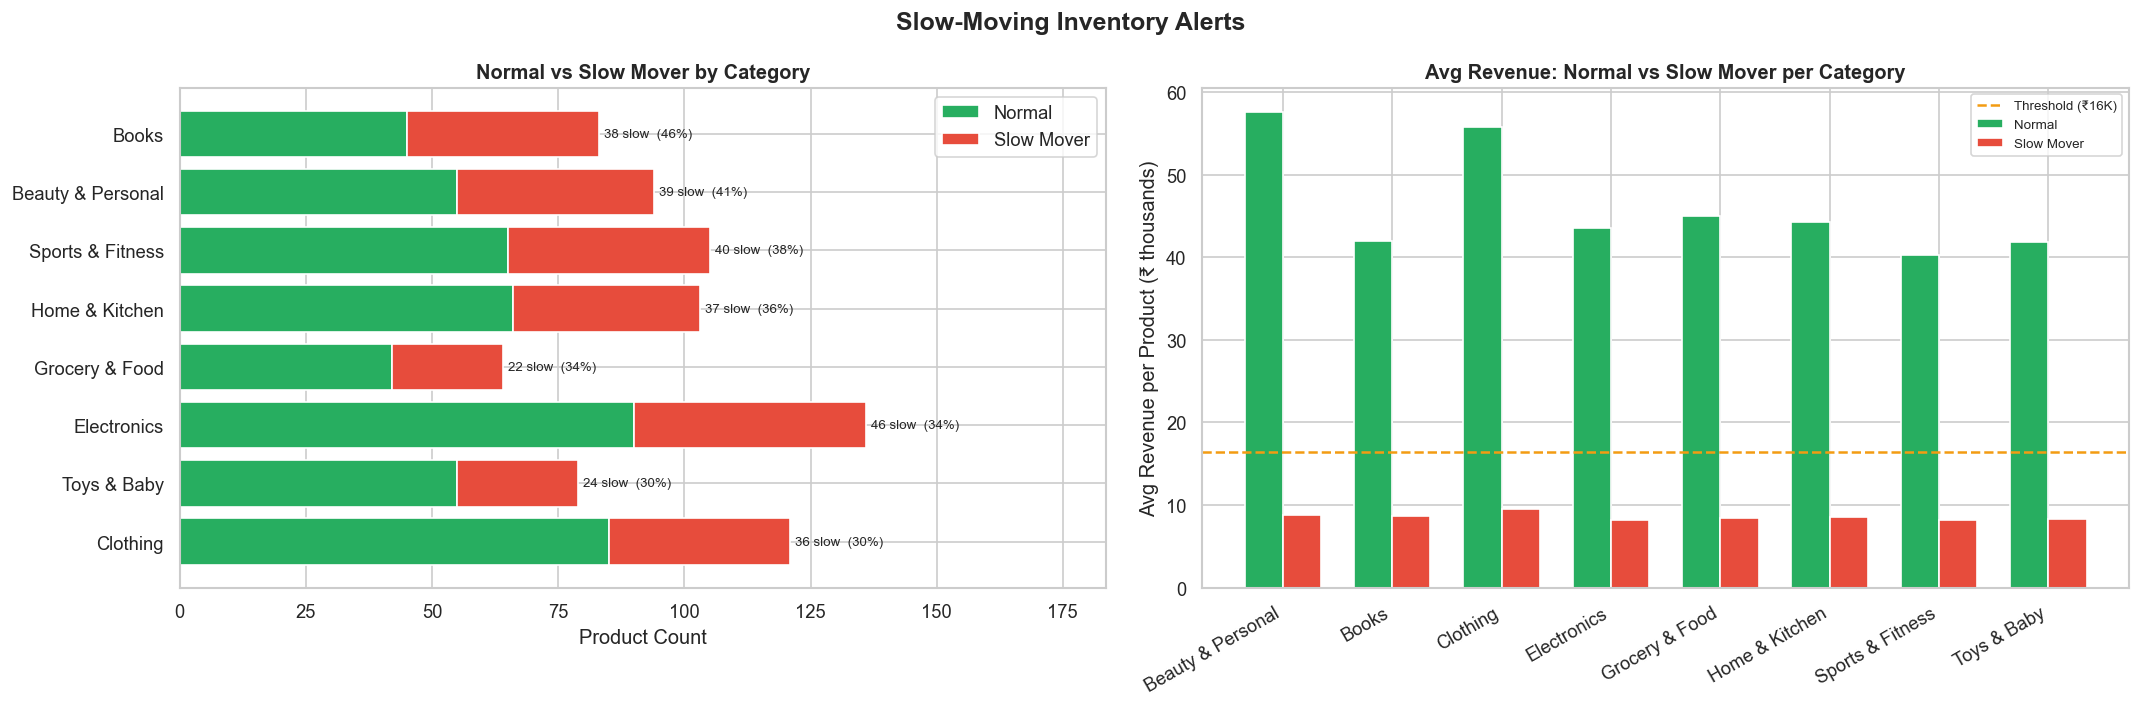

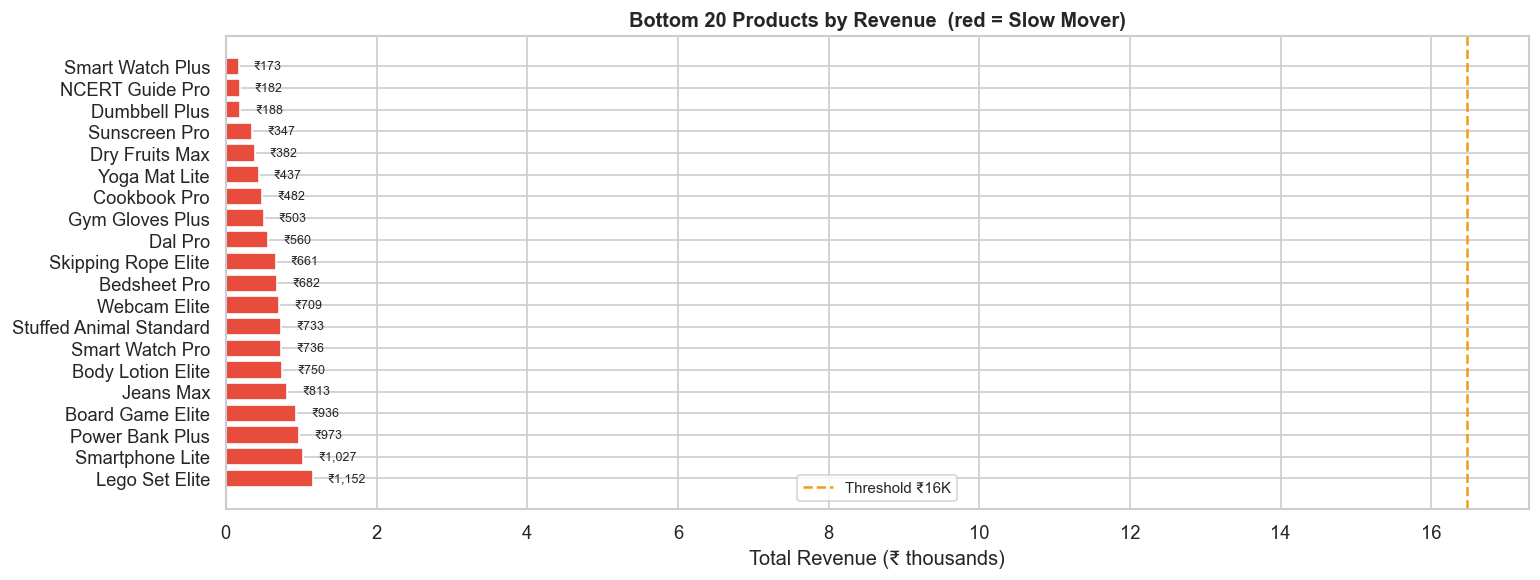


── Slow Movers by Category ──
slow_mover_flag    Slow Mover  Normal  Total   Slow_Pct
product_category                                       
Books                      38      45     83  45.783133
Beauty & Personal          39      55     94  41.489362
Sports & Fitness           40      65    105  38.095238
Home & Kitchen             37      66    103  35.922330
Grocery & Food             22      42     64  34.375000
Electronics                46      90    136  33.823529
Toys & Baby                24      55     79  30.379747
Clothing                   36      85    121  29.752066

── Top 20 Slow Movers (lowest revenue) ──


,product_name,product_category,brand,total_revenue,units_sold,stock_qty,revenue_vs_avg_pct
0,Smart Watch Plus,Electronics,Bata,172.80,1,154,0.5
1,NCERT Guide Pro,Books,Godrej,181.63,1,442,0.6
2,Dumbbell Plus,Sports & Fitness,Wildcraft,187.79,1,71,0.6
3,Sunscreen Pro,Beauty & Personal,Peter England,347.09,1,263,1.1
4,Dry Fruits Max,Grocery & Food,Dabur,381.81,3,211,1.2
5,Yoga Mat Lite,Sports & Fitness,W for Woman,437.06,2,411,1.3
6,Cookbook Pro,Books,Amul,482.17,1,228,1.5
7,Gym Gloves Plus,Sports & Fitness,Marico,502.58,2,297,1.5
8,Dal Pro,Grocery & Food,Boat,560.12,4,96,1.7
9,Skipping Rope Elite,Sports & Fitness,W for Woman,661.31,3,460,2.0



Exported slow_mover_powerbi.csv  →  785 rows


In [20]:
# =========================
# Section 14: Slow-Moving Inventory Alerts
# =========================

# ── Build product-level revenue summary ──────────────────────────────────────
delivered_ids = orders.loc[orders["order_status"] == "delivered", "order_id"]
items_full = (
    order_items[order_items["order_id"].isin(delivered_ids)]
    .merge(products[["product_id", "product_name", "product_category",
                      "brand", "stock_qty"]], on="product_id", how="left")
)

prod_rev = (
    items_full.groupby(["product_id", "product_name", "product_category", "brand", "stock_qty"])
    .agg(
        total_revenue=("total_value",  "sum"),
        units_sold=("quantity",        "sum"),
        order_count=("order_id",       "nunique"),
    )
    .reset_index()
)

avg_revenue  = prod_rev["total_revenue"].mean()
threshold    = avg_revenue * 0.5

prod_rev["slow_mover_flag"] = prod_rev["total_revenue"].apply(
    lambda x: "Slow Mover" if x < threshold else "Normal"
)
prod_rev["revenue_vs_avg_pct"] = (prod_rev["total_revenue"] / avg_revenue * 100).round(1)

slow   = prod_rev[prod_rev["slow_mover_flag"] == "Slow Mover"]
normal = prod_rev[prod_rev["slow_mover_flag"] == "Normal"]

print(f"Avg product revenue       : ₹{avg_revenue:,.0f}")
print(f"Slow-mover threshold (<50%): ₹{threshold:,.0f}")
print(f"Slow Movers               : {len(slow):,}  ({len(slow)/len(prod_rev)*100:.1f}%)")
print(f"Normal                    : {len(normal):,}  ({len(normal)/len(prod_rev)*100:.1f}%)")

# ── Figure 1 : Slow mover count by category + revenue gap bar ────────────────
slow_by_cat = (
    prod_rev.groupby(["product_category", "slow_mover_flag"])
    .size().unstack(fill_value=0)
    .reindex(columns=["Slow Mover", "Normal"])
)
slow_by_cat["Total"]    = slow_by_cat.sum(axis=1)
slow_by_cat["Slow_Pct"] = slow_by_cat["Slow Mover"] / slow_by_cat["Total"] * 100
slow_by_cat = slow_by_cat.sort_values("Slow_Pct", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Slow-Moving Inventory Alerts", fontsize=15, fontweight="bold")

# Left — stacked bar: Normal vs Slow Mover per category
ax1 = axes[0]
ax1.barh(slow_by_cat.index, slow_by_cat["Normal"],
         color="#27ae60", label="Normal", edgecolor="white")
ax1.barh(slow_by_cat.index, slow_by_cat["Slow Mover"],
         left=slow_by_cat["Normal"], color="#e74c3c",
         label="Slow Mover", edgecolor="white")
ax1.invert_yaxis()
ax1.set_xlabel("Product Count")
ax1.set_title("Normal vs Slow Mover by Category", fontweight="bold")
ax1.legend()
for i, (idx, row) in enumerate(slow_by_cat.iterrows()):
    ax1.text(row["Total"] + 1, i,
             f"{row['Slow Mover']:.0f} slow  ({row['Slow_Pct']:.0f}%)",
             va="center", fontsize=8)
ax1.set_xlim(0, slow_by_cat["Total"].max() * 1.35)

# Right — Avg revenue: Normal vs Slow Mover per category
avg_by_cat = (
    prod_rev.groupby(["product_category", "slow_mover_flag"])["total_revenue"]
    .mean().unstack(fill_value=0)
)
x      = range(len(avg_by_cat))
width  = 0.35
ax2    = axes[1]
ax2.bar([i - width/2 for i in x], avg_by_cat.get("Normal", 0) / 1000,
        width, color="#27ae60", label="Normal", edgecolor="white")
ax2.bar([i + width/2 for i in x], avg_by_cat.get("Slow Mover", 0) / 1000,
        width, color="#e74c3c", label="Slow Mover", edgecolor="white")
ax2.axhline(threshold / 1000, color="#f39c12", linestyle="--",
            linewidth=1.5, label=f"Threshold (₹{threshold/1000:.0f}K)")
ax2.set_xticks(list(x))
ax2.set_xticklabels(avg_by_cat.index, rotation=30, ha="right")
ax2.set_ylabel("Avg Revenue per Product (₹ thousands)")
ax2.set_title("Avg Revenue: Normal vs Slow Mover per Category", fontweight="bold")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Figure 2 : Bottom 20 products (revenue scatter) ──────────────────────────
bottom20 = prod_rev.nsmallest(20, "total_revenue").reset_index(drop=True)
fig2, ax = plt.subplots(figsize=(13, 5))
colors_b = ["#e74c3c" if f == "Slow Mover" else "#27ae60"
            for f in bottom20["slow_mover_flag"]]
bars = ax.barh(bottom20["product_name"], bottom20["total_revenue"] / 1000,
               color=colors_b, edgecolor="white")
ax.invert_yaxis()
ax.axvline(threshold / 1000, color="#f39c12", linestyle="--",
           linewidth=1.5, label=f"Threshold ₹{threshold/1000:.0f}K")
ax.set_xlabel("Total Revenue (₹ thousands)")
ax.set_title("Bottom 20 Products by Revenue  (red = Slow Mover)", fontweight="bold")
ax.legend(fontsize=9)
for bar, row in zip(bars, bottom20.itertuples()):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f"₹{row.total_revenue:,.0f}", va="center", fontsize=7.5)
plt.tight_layout()
plt.show()

# ── Print & export ────────────────────────────────────────────────────────────
print("\n── Slow Movers by Category ──")
print(slow_by_cat[["Slow Mover", "Normal", "Total", "Slow_Pct"]].to_string())

print("\n── Top 20 Slow Movers (lowest revenue) ──")
display(slow.nsmallest(20, "total_revenue")[
    ["product_name", "product_category", "brand",
     "total_revenue", "units_sold", "stock_qty", "revenue_vs_avg_pct"]
].reset_index(drop=True))

slow_export = prod_rev[[
    "product_id", "product_name", "product_category", "brand",
    "total_revenue", "units_sold", "order_count",
    "stock_qty", "slow_mover_flag", "revenue_vs_avg_pct"
]]
slow_export.to_csv("slow_mover_powerbi.csv", index=False)
print(f"\nExported slow_mover_powerbi.csv  →  {len(slow_export):,} rows")

Highest margin state  : Haryana  (32.3%)
Lowest  margin state  : Uttar Pradesh  (21.0%)


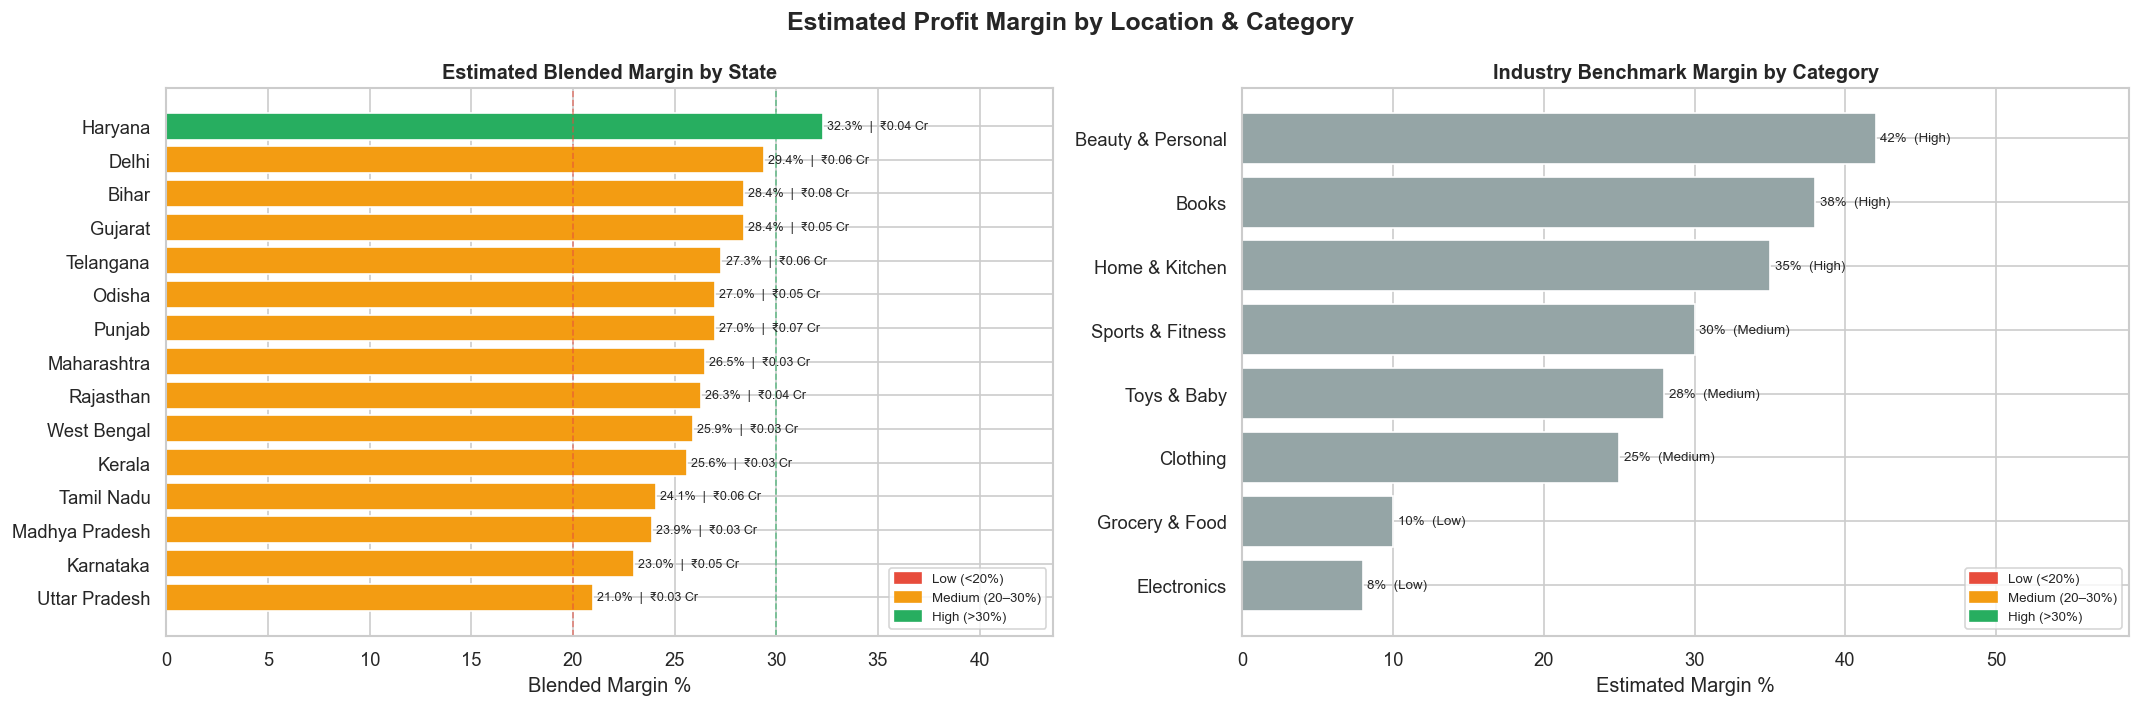

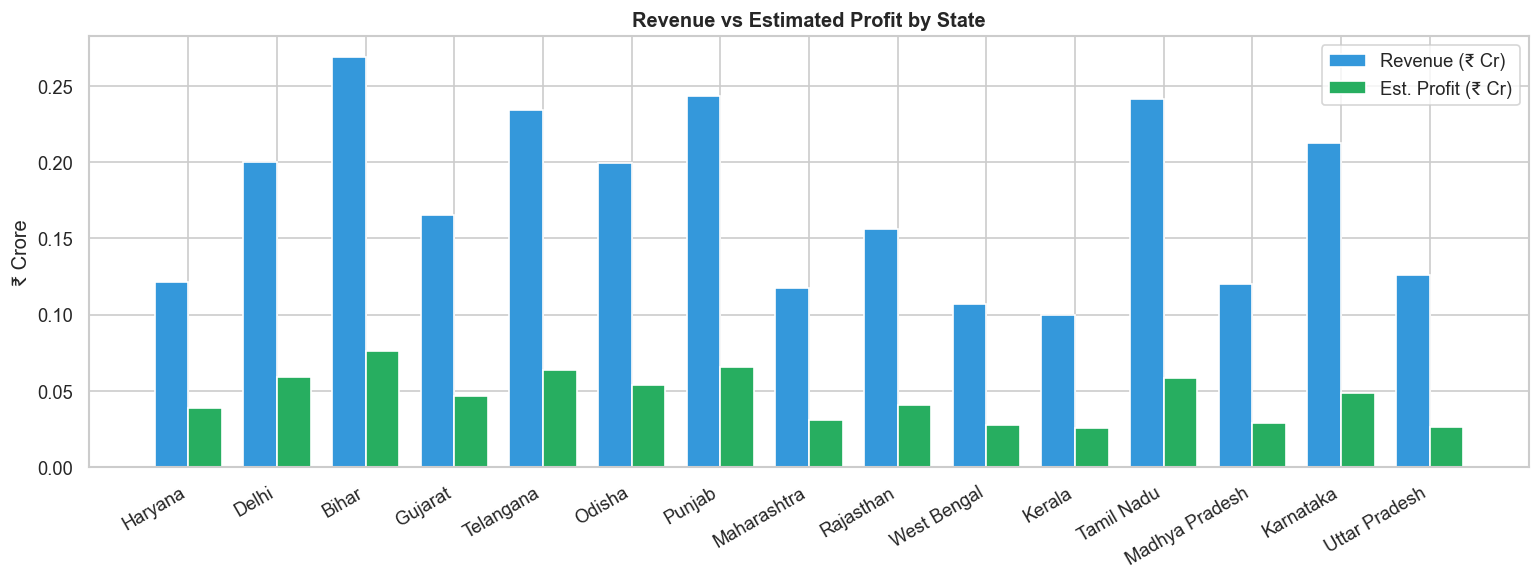


── State Margin Summary ──
customer_state  total_revenue  est_profit  blended_margin_pct     margin_tier
       Haryana     1211003.03 391483.5161                32.3     High (>30%)
         Delhi     2002278.20 589078.1919                29.4 Medium (20–30%)
         Bihar     2690248.62 762903.8799                28.4 Medium (20–30%)
       Gujarat     1652818.72 470012.8338                28.4 Medium (20–30%)
     Telangana     2342630.70 639222.4151                27.3 Medium (20–30%)
        Odisha     1991076.08 537338.0721                27.0 Medium (20–30%)
        Punjab     2435755.73 657353.3365                27.0 Medium (20–30%)
   Maharashtra     1172859.26 310804.5587                26.5 Medium (20–30%)
     Rajasthan     1562144.55 410248.0630                26.3 Medium (20–30%)
   West Bengal     1066914.05 276253.3550                25.9 Medium (20–30%)
        Kerala      996063.01 254566.0098                25.6 Medium (20–30%)
    Tamil Nadu     2415704.60 583330

In [21]:
# =========================
# Section 15: Profit Margin by Location (Estimated Tier)
# =========================
# No cost column in dataset — margin tiers estimated by category
# based on standard Indian e-commerce industry benchmarks.

# ── Category margin tier mapping ──────────────────────────────────────────────
category_margin = {
    "Electronics":         ("Low",    8),
    "Grocery & Food":      ("Low",    10),
    "Clothing":            ("Medium", 25),
    "Toys & Baby":         ("Medium", 28),
    "Sports & Fitness":    ("Medium", 30),
    "Home & Kitchen":      ("High",   35),
    "Books":               ("High",   38),
    "Beauty & Personal":   ("High",   42),
}

# ── Build location + category revenue base ────────────────────────────────────
delivered_ids = orders.loc[orders["order_status"] == "delivered", "order_id"]
items_loc = (
    order_items[order_items["order_id"].isin(delivered_ids)]
    .merge(products[["product_id", "product_category"]], on="product_id", how="left")
    .merge(orders[["order_id", "customer_id"]], on="order_id", how="left")
    .merge(customers[["customer_id", "customer_state"]], on="customer_id", how="left")
)

state_cat_rev = (
    items_loc.groupby(["customer_state", "product_category"])["total_value"]
    .sum().reset_index(name="revenue")
)

state_cat_rev["margin_tier"]    = state_cat_rev["product_category"].map(
    lambda c: category_margin.get(c, ("Medium", 25))[0])
state_cat_rev["margin_pct"]     = state_cat_rev["product_category"].map(
    lambda c: category_margin.get(c, ("Medium", 25))[1])
state_cat_rev["est_profit"]     = state_cat_rev["revenue"] * state_cat_rev["margin_pct"] / 100

# ── State-level summary ───────────────────────────────────────────────────────
state_margin = (
    state_cat_rev.groupby("customer_state")
    .agg(
        total_revenue=("revenue",     "sum"),
        est_profit=("est_profit",     "sum"),
    )
    .reset_index()
)
state_margin["blended_margin_pct"] = (
    state_margin["est_profit"] / state_margin["total_revenue"] * 100
).round(1)
state_margin["margin_tier"] = pd.cut(
    state_margin["blended_margin_pct"],
    bins=[0, 20, 30, 100],
    labels=["Low (<20%)", "Medium (20–30%)", "High (>30%)"]
)
state_margin["profit_cr"] = state_margin["est_profit"] / 1e7
state_margin = state_margin.sort_values("blended_margin_pct", ascending=False)

# ── Category-level summary ────────────────────────────────────────────────────
cat_margin_df = pd.DataFrame([
    {"product_category": cat,
     "margin_tier": v[0],
     "margin_pct":  v[1]}
    for cat, v in category_margin.items()
]).sort_values("margin_pct", ascending=False)
cat_margin_df["total_revenue"] = cat_margin_df["product_category"].map(
    state_cat_rev.groupby("product_category")["revenue"].sum())
cat_margin_df["est_profit"] = cat_margin_df["total_revenue"] * cat_margin_df["margin_pct"] / 100

print(f"Highest margin state  : {state_margin.iloc[0]['customer_state']}"
      f"  ({state_margin.iloc[0]['blended_margin_pct']:.1f}%)")
print(f"Lowest  margin state  : {state_margin.iloc[-1]['customer_state']}"
      f"  ({state_margin.iloc[-1]['blended_margin_pct']:.1f}%)")

# ── Figure 1 : State margin bar + category margin bar ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Estimated Profit Margin by Location & Category",
             fontsize=15, fontweight="bold")

tier_colors_map = {
    "Low (<20%)":      "#e74c3c",
    "Medium (20–30%)": "#f39c12",
    "High (>30%)":     "#27ae60",
}
state_colors = [tier_colors_map.get(str(t), "#95a5a6")
                for t in state_margin["margin_tier"]]

# Left — blended margin % by state
ax1 = axes[0]
bars1 = ax1.barh(state_margin["customer_state"],
                 state_margin["blended_margin_pct"],
                 color=state_colors, edgecolor="white")
ax1.invert_yaxis()
ax1.set_xlabel("Blended Margin %")
ax1.set_title("Estimated Blended Margin by State", fontweight="bold")
ax1.axvline(20, color="#e74c3c", linestyle="--", linewidth=1, alpha=0.6)
ax1.axvline(30, color="#27ae60", linestyle="--", linewidth=1, alpha=0.6)
for bar, row in zip(bars1, state_margin.itertuples()):
    ax1.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
             f"{row.blended_margin_pct:.1f}%  |  ₹{row.profit_cr:.2f} Cr",
             va="center", fontsize=7.5)
ax1.set_xlim(0, state_margin["blended_margin_pct"].max() * 1.35)

# Add legend patches
from matplotlib.patches import Patch
legend_els = [Patch(color=c, label=t) for t, c in tier_colors_map.items()]
ax1.legend(handles=legend_els, fontsize=8, loc="lower right")

# Right — margin % by category (horizontal bar)
cat_colors = [tier_colors_map.get(t, "#95a5a6") for t in cat_margin_df["margin_tier"]]
ax2 = axes[1]
bars2 = ax2.barh(cat_margin_df["product_category"],
                 cat_margin_df["margin_pct"],
                 color=cat_colors, edgecolor="white")
ax2.invert_yaxis()
ax2.set_xlabel("Estimated Margin %")
ax2.set_title("Industry Benchmark Margin by Category", fontweight="bold")
for bar, row in zip(bars2, cat_margin_df.itertuples()):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
             f"{row.margin_pct}%  ({row.margin_tier})",
             va="center", fontsize=8)
ax2.set_xlim(0, cat_margin_df["margin_pct"].max() * 1.4)
ax2.legend(handles=legend_els, fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

# ── Figure 2 : Revenue vs Estimated Profit by state ──────────────────────────
fig2, ax = plt.subplots(figsize=(13, 5))
x     = range(len(state_margin))
width = 0.38
ax.bar([i - width/2 for i in x],
       state_margin["total_revenue"] / 1e7,
       width, color="#3498db", label="Revenue (₹ Cr)", edgecolor="white")
ax.bar([i + width/2 for i in x],
       state_margin["profit_cr"],
       width, color="#27ae60", label="Est. Profit (₹ Cr)", edgecolor="white")
ax.set_xticks(list(x))
ax.set_xticklabels(state_margin["customer_state"], rotation=30, ha="right")
ax.set_ylabel("₹ Crore")
ax.set_title("Revenue vs Estimated Profit by State", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

# ── Print tables ──────────────────────────────────────────────────────────────
print("\n── State Margin Summary ──")
print(state_margin[["customer_state", "total_revenue", "est_profit",
                     "blended_margin_pct", "margin_tier"]].to_string(index=False))

print("\n── Category Margin Benchmarks Used ──")
print(cat_margin_df[["product_category", "margin_tier", "margin_pct",
                      "total_revenue", "est_profit"]].to_string(index=False))
print("\n⚠️  Note: Margin % are industry benchmark estimates (no cost data in dataset).")
print("   Load actual cost data to replace with precise margins.")

# ── Export ────────────────────────────────────────────────────────────────────
state_margin.to_csv("profit_margin_by_state_powerbi.csv", index=False)
cat_margin_df.to_csv("profit_margin_by_category_powerbi.csv", index=False)
print(f"\nExported profit_margin_by_state_powerbi.csv      →  {len(state_margin)} rows")
print(f"Exported profit_margin_by_category_powerbi.csv  →  {len(cat_margin_df)} rows")

In [22]:
# =========================
# Section 16: Export Product Summary for Power BI
# =========================

delivered_orders = orders.loc[orders["order_status"].eq("delivered")].copy()
delivered_orders["order_purchase_timestamp"] = pd.to_datetime(
    delivered_orders["order_purchase_timestamp"], format="mixed", errors="coerce"
)

product_master = (
    order_items.merge(delivered_orders[["order_id", "order_purchase_timestamp"]], on="order_id", how="inner")
    .merge(products, on="product_id", how="left", suffixes=("", "_prod"))
)

product_master["discount_amount"] = (product_master["unit_price"] - product_master["selling_price"]) * product_master["quantity"]
product_master["year"] = product_master["order_purchase_timestamp"].dt.year
product_master["month"] = product_master["order_purchase_timestamp"].dt.month

# Product-level summary for Power BI
product_summary_for_powerbi = (
    product_master.groupby(
        ["year", "month", "product_category", "brand", "product_name"], dropna=False
    )
    .agg(
        total_orders=("order_id", "nunique"),
        total_quantity_sold=("quantity", "sum"),
        total_revenue=("total_value", "sum"),
        avg_selling_price=("selling_price", "mean"),
        total_discount=("discount_amount", "sum"),
        total_freight=("freight_value", "sum"),
        avg_weight=("weight_grams", "mean")
    )
    .reset_index()
    .sort_values(["year", "month", "product_category", "brand"])
)

# Category-level summary
category_summary_for_powerbi = (
    product_master.groupby(
        ["year", "month", "product_category"], dropna=False
    )
    .agg(
        total_orders=("order_id", "nunique"),
        total_quantity_sold=("quantity", "sum"),
        total_revenue=("total_value", "sum"),
        unique_products=("product_id", "nunique"),
        unique_brands=("brand", "nunique"),
        total_discount=("discount_amount", "sum"),
        total_freight=("freight_value", "sum")
    )
    .reset_index()
    .sort_values(["year", "month", "product_category"])
)

# Export
prod_file = "product_summary_for_powerbi.csv"
cat_file = "category_summary_for_powerbi.csv"

product_summary_for_powerbi.to_csv(prod_file, index=False)
category_summary_for_powerbi.to_csv(cat_file, index=False)

print(f"Exported {len(product_summary_for_powerbi):,} rows to {prod_file}")
print(f"Exported {len(category_summary_for_powerbi):,} rows to {cat_file}")

print("\nProduct Summary Preview:")
display(product_summary_for_powerbi.head(3))

print("\nCategory Summary Preview:")
display(category_summary_for_powerbi.head(3))

Exported 855 rows to product_summary_for_powerbi.csv
Exported 270 rows to category_summary_for_powerbi.csv

Product Summary Preview:


,year,month,product_category,brand,product_name,total_orders,total_quantity_sold,total_revenue,avg_selling_price,total_discount,total_freight,avg_weight
0,2022,1,Beauty & Personal,Bajaj,Sunscreen Elite,1,4,62073.46,15496.28,0.00,88.34,2975.0
1,2022,1,Beauty & Personal,OnePlus,Face Wash Elite,1,2,28418.30,14115.89,0.00,186.52,4599.0
2,2022,1,Beauty & Personal,Tata,Face Wash Pro,1,2,9191.16,4595.58,1621.96,0.00,1291.0



Category Summary Preview:


,year,month,product_category,total_orders,total_quantity_sold,total_revenue,unique_products,unique_brands,total_discount,total_freight
0,2022,1,Beauty & Personal,3,8,99682.92,3,3,1621.96,274.86
1,2022,1,Books,2,10,172131.60,2,2,28186.88,154.88
2,2022,1,Clothing,2,4,69751.59,2,2,584.73,158.21
